# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')


In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.variables import *
from core.dgp import SingleSegmentTreatmentSelection as SingleSegment
import core.treatment_selection_single_segment as ts
import core.m_out_of_n_bootstrap as mn 

# DGP

In [5]:
dgp = SingleSegment(
    te_arr = np.array([0.1, 0.2]), noise_std=1, response_type='continuous',
)
treatment_arr, outcome_arr = dgp.sample(sample_size=100, seed=0)

# Demand Model

In [8]:
emp_te_arr = ts.estimate_te(treatment_arr, outcome_arr, response_type='continuous')

for te_true, te_est in zip(dgp.te_arr, emp_te_arr):
    print(f"True TE: {te_true}, Estimated TE: {te_est:.4f}")

True TE: 0.1, Estimated TE: 0.1258
True TE: 0.2, Estimated TE: 0.2865


# Optimization

In [9]:
plugin_decision, plugin_val_est = ts.optimize(te_arr=emp_te_arr)
true_plugin_val = ts.obj_func(targ_decision=plugin_decision, te_arr=dgp.te_arr)

print(f'Plugin Decision: {plugin_decision}')
print(f'Estimated Targeting Value: {plugin_val_est:.2f}')
print(f'True Targeting Value: {true_plugin_val:.2f}')

print()
print(f"Winner's curse (measured in MPE): {100 * (plugin_val_est - true_plugin_val)/true_plugin_val:.2f}%")

Plugin Decision: 1
Estimated Targeting Value: 0.29
True Targeting Value: 0.20

Winner's curse (measured in MPE): 43.27%


## Shape of the Value function

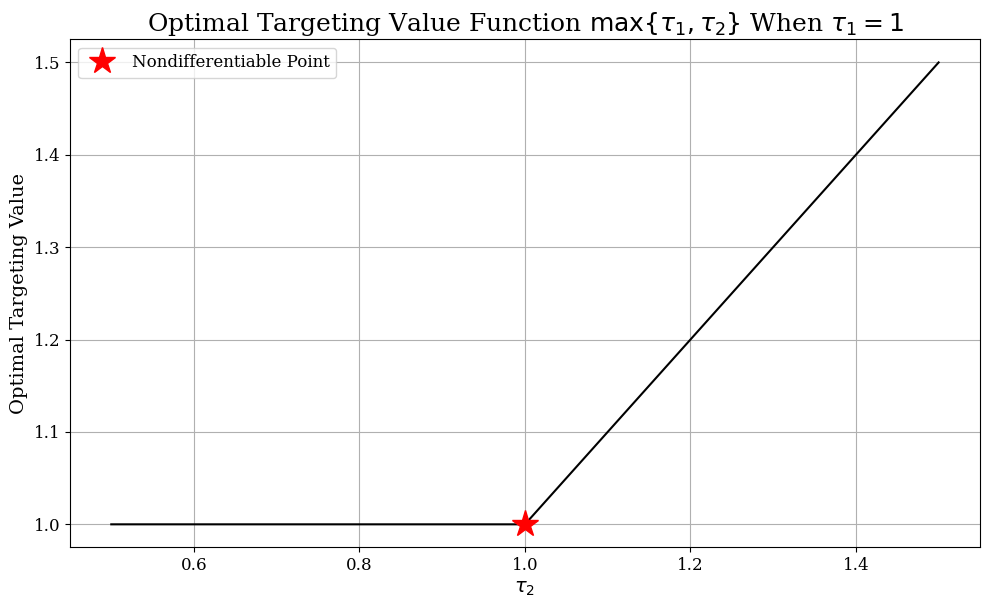

In [10]:
tau1 = 1
tau2_arr = np.linspace(0.5, 1.5, 1000)

val_arr = np.array([ts.optimize(te_arr=np.array([tau1, tau2]))[1] for tau2 in tau2_arr])

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.plot(tau2_arr, val_arr, color='black')


# mark discontinuous point
ax.plot(tau1, tau1, 'r*', markersize=20, label='Nondifferentiable Point')

# plot attributes
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_title(r'Optimal Targeting Value Function $\max\{\tau_1, \tau_2\}$ When $\tau_1 = 1$', fontsize=title_size)
ax.set_xlabel(r'$\tau_2$', fontsize=axis_label_size)
ax.set_ylabel('Optimal Targeting Value', fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()


# Winner's Curse

In [11]:
operations_params = {}

dgp_params = {'te_arr': np.array([1, 1.1]), 'noise_std': 1, 'response_type': 'continuous'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

# empirical distribution of winner's curse
estimators_dict = {}

result_records = ts.repeated_experiments(
    operations_params=operations_params,
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=False, 
)

wc_measures_dict = ts.calculate_winners_curse_measures(
    result_records=result_records, 
    estimators_dict=estimators_dict, data_params=data_params
)

print(f"Average Estimated Targeting Value: {wc_measures_dict['nc_val_est_avg']:.4f} ({wc_measures_dict['nc_val_est_se']:.4f})")
print(f"Average True Targeting Value: {wc_measures_dict['nc_val_true_avg']:.4f} ({wc_measures_dict['nc_val_true_se']:.4f})")
print(f"Average Winner's Curse: {wc_measures_dict['nc_wc_avg']:.4f} ({wc_measures_dict['nc_wc_se']:.4f})")

Average Estimated Targeting Value: 1.1390 (0.0120)
Average True Targeting Value: 1.0675 (0.0047)
Average Winner's Curse: 0.0715 (0.0122)


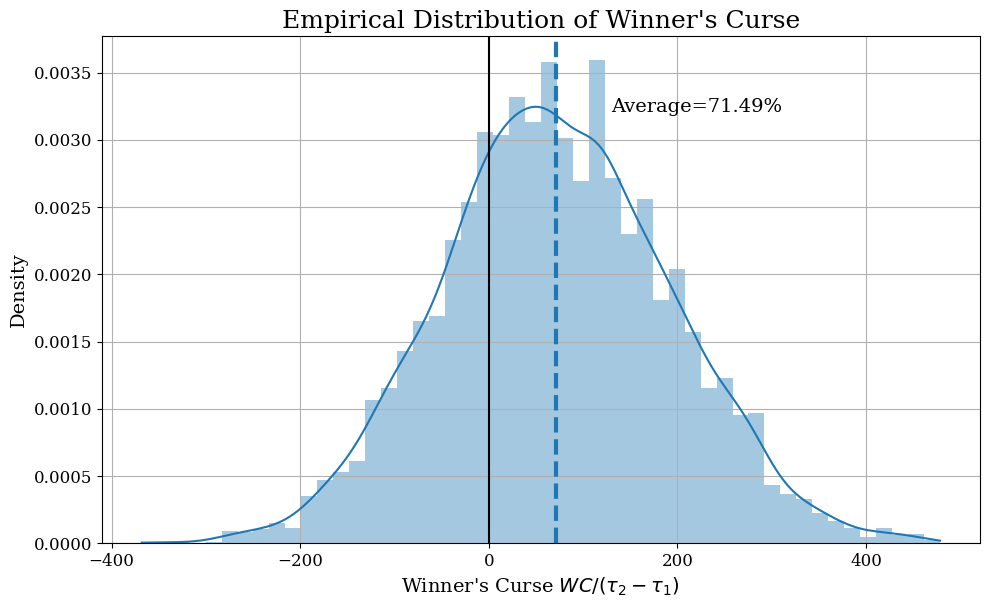

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
sns.histplot(100 * wc_measures_dict['nc_wc_arr'] / delta_tau, bins=50, kde=True, stat='density', ax=ax, color='C0', alpha=0.4, edgecolor=None)
ax.axvline(100 * wc_measures_dict['nc_wc_avg'] / delta_tau, color='C0', linestyle='--', linewidth=3)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5)
ax.annotate(
    f"Average={100 * wc_measures_dict['nc_wc_avg'] / delta_tau:.2f}%", 
    xy=(0.58, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel(r"Winner's Curse $WC / (\tau_2 - \tau_1)$ ", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Estimating Winner's Curse

In [13]:
dgp = SingleSegment(**dgp_params)
treatment_arr, outcome_arr = dgp.sample(100)

## Standard Bootstrap

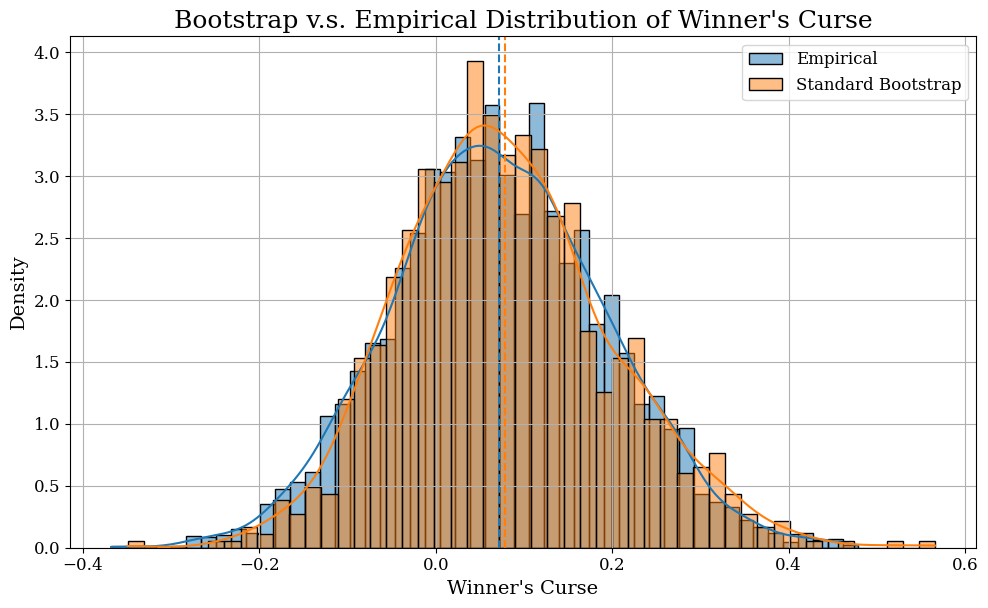

In [14]:
# generate bootstrap distribution
boot_wc_dstn_arr = ts.get_wc_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, n_bootstraps=1000, response_type=dgp_params['response_type']
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n bootstrap

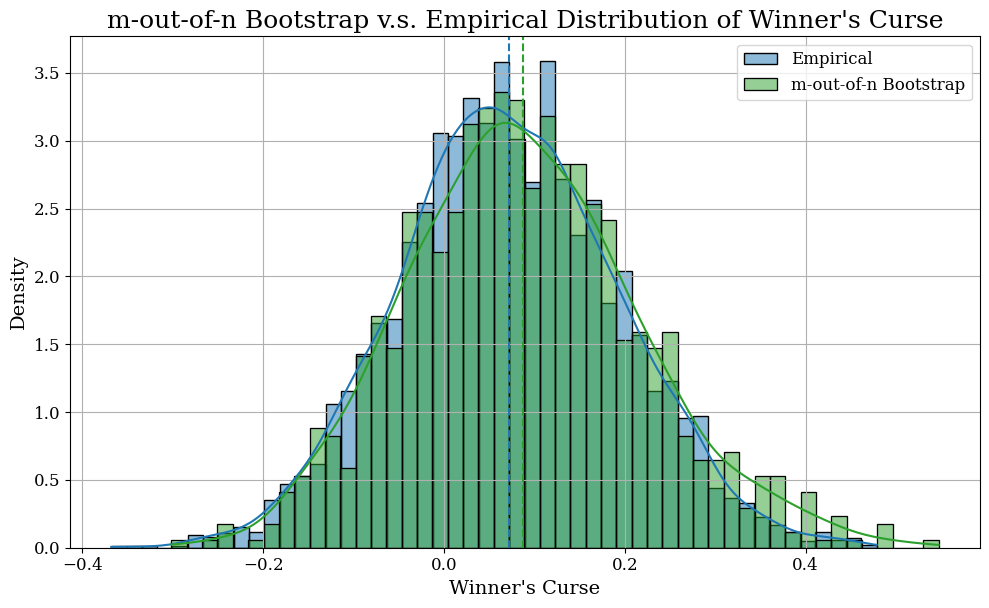

In [15]:
# generate bootstrap distribution
boot_wc_dstn_arr = ts.get_wc_m_out_of_n_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, power=0.95, n_bootstraps=1000, conditional_on_treated=True, response_type=dgp_params['response_type']
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

100%|██████████| 7/7 [00:01<00:00,  3.53it/s]

Best m-out-of-n Power: 0.80


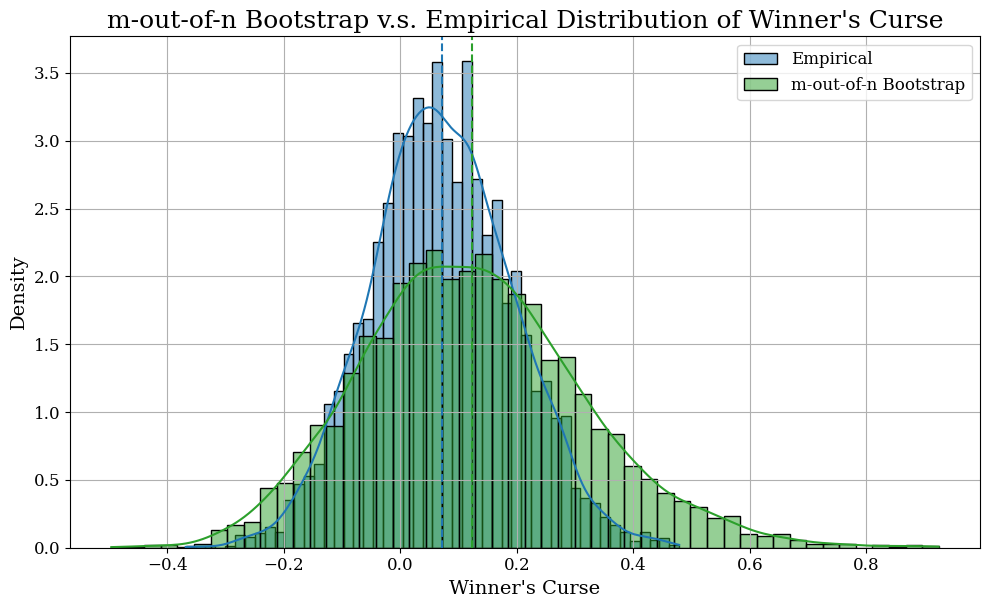

In [54]:
candidate_power_arr = np.array([0.70, 0.75, 0.80, 0.85, 0.90, 0.85, 0.99])[::-1]

wc_dstn_list = [
    ts.get_wc_m_out_of_n_boot_dstn(
        treatments=treatment_arr, outcomes=outcome_arr,
        **operations_params, power=power, n_bootstraps=5000, conditional_on_treated=True, response_type=dgp_params['response_type']
    ) for power in tqdm(candidate_power_arr)
]

best_m_idx = mn.choose_best_m(wc_dstn_list)

print(f"Best m-out-of-n Power: {candidate_power_arr[best_m_idx]:.2f}")

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(wc_dstn_list[best_m_idx], bins=50, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(wc_dstn_list[best_m_idx].mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

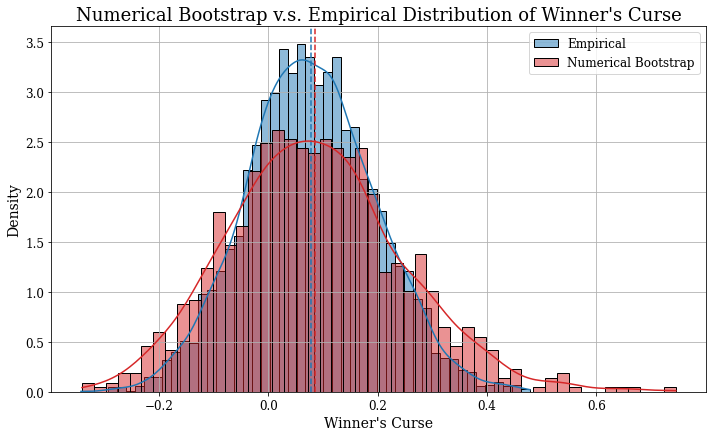

In [15]:
# generate bootstrap distribution
boot_wc_dstn_arr = ts.get_wc_num_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, power=-0.45, n_bootstraps=1000, conditional_on_treated=True, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Numerical Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [5]:
operations_params = {}

dgp_params = {'te_arr': np.array([1, 1.1]), 'noise_std': 1, 'response_type': 'continuous'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

estimators_dict = {
    'sample_splitting': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {}, 
        'display_name': 'Sample Splitting'
    }, 
    'cross_validation': {
        'estimator': ts.cross_validation_estimate,
        'params': {'n_splits': 5},
        'display_name': 'Cross Validation'
    }, 
    'empirical_bayes': {
        'estimator': ts.empirical_bayes_estimate, 
        'params': {'dof': 5, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes \nEfron 2011, JASA'
    }, 
    'normal_prior_bayes': {
        'estimator': ts.normal_prior_bayes_estimate, 
        'params': {'prior_mean': 0, 'prior_std': 1}, 
        'display_name': 'Normal Prior Bayes \nKessler 2024, Amazon'
    }, 
    'conditional_selective_inference':{
        'estimator': ts.conditional_selective_inference,
        'params': {'quantile': 0.5}, 
        'display_name': 'Andrews et al. 2024, QJE'
    }, 
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 'auto', 'n_jobs': 1,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }, 
        'display_name': 'Numerical Bootstrap'
    }, 
}

In [6]:
result_records = ts.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = ts.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   19.8s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   30.3s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   43.0s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   58.1s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  2.0min finished


In [8]:
wc_dict = {}
delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 
print("Overestimated Profit Lift: ")
wc_df.round(2)

Overestimated Profit Lift: 


,Avg. Winner's Curse (%),S.E. Winner's Curse (%),Median Winner's Curse (%)
No Correction,71.49,12.15,67.85
Sample Splitting,-4.75,20.33,-6.17
Cross Validation,-2.46,17.46,7.32
"Empirical Bayes \nEfron 2011, JASA",-1.40,73.37,-12.25
"Normal Prior Bayes \nKessler 2024, Amazon",49.28,11.94,45.90
"Andrews et al. 2024, QJE",-426.13,708.84,3.12
Standard Bootstrap,18.95,13.38,14.13
m-out-of-n Bootstrap,-20.06,13.70,-26.53
Numerical Bootstrap,5.53,13.75,0.37


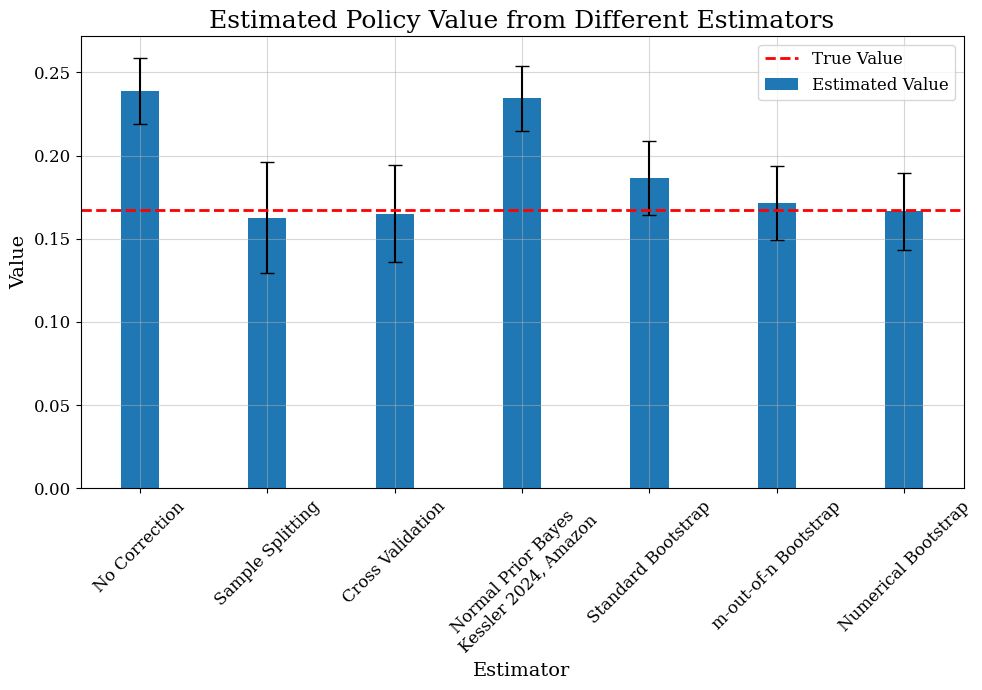

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

viz_estimators_list = ['nc', 'sample_splitting', 'cross_validation', 'normal_prior_bayes', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']
obj_val_list = [wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in viz_estimators_list]

ax.bar(
    x=np.arange(len(viz_estimators_list)), 
    height=obj_val_list, 
    yerr=[1.65 * wc_measures_dict[f'{estimator}_val_est_se'] for estimator in viz_estimators_list],
    capsize=5, color='C0', width=0.3
)

ax.axhline(wc_measures_dict['nc_val_true_avg'], color='red', linestyle='--', linewidth=2)

ax.set_title("Estimated Policy Value from Different Estimators", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(viz_estimators_list)))
ax.set_xticklabels(['No Correction'] + [estimators_dict[estimator]['display_name'] for estimator in viz_estimators_list[1:]], rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

ax.legend(['True Value', 'Estimated Value'], fontsize=legend_label_size)

ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

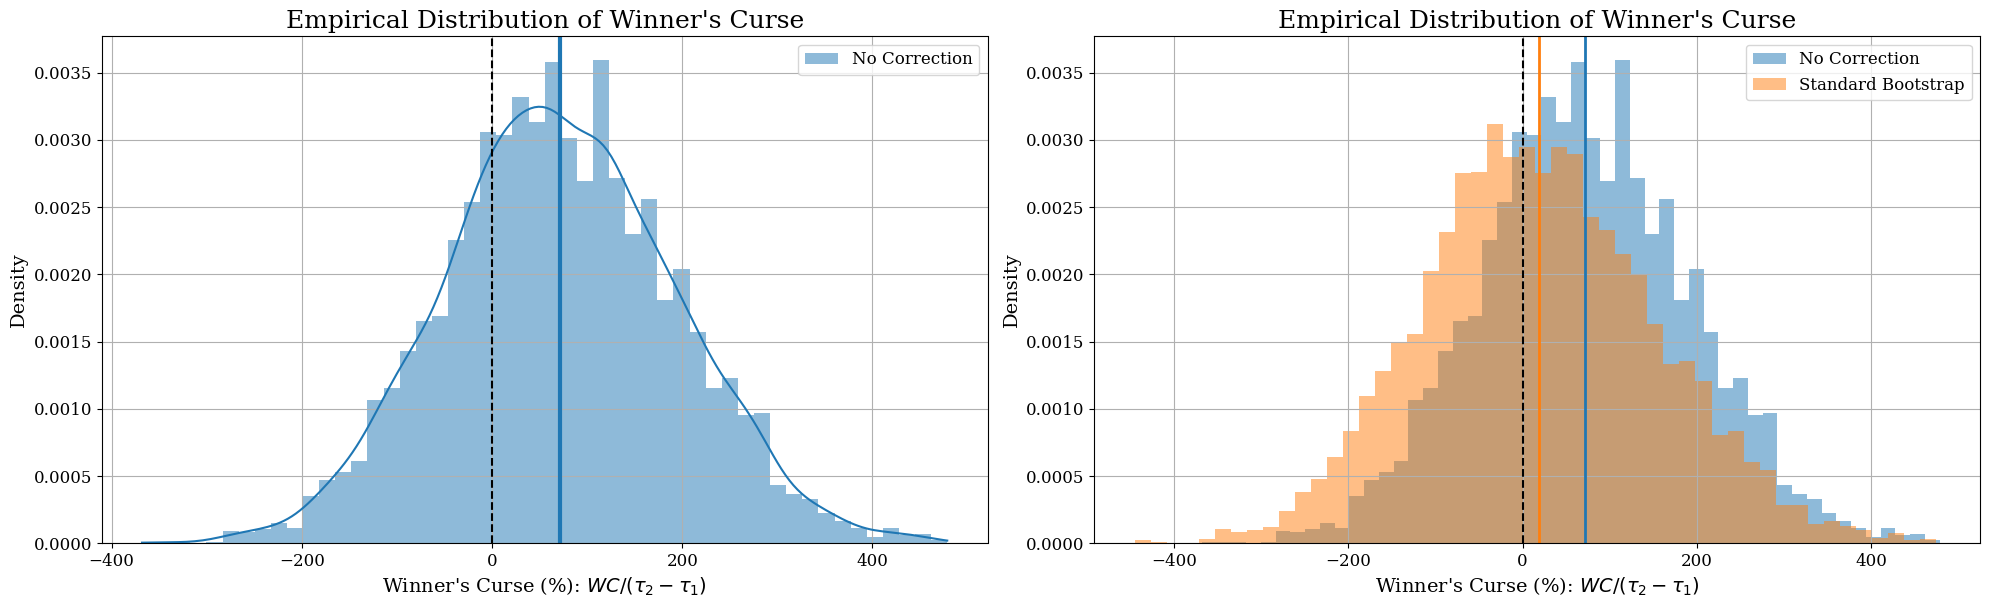

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]

# winner's curse of no correction
sns.histplot(
    100 * wc_measures_dict['nc_wc_arr'] / delta_tau,
    bins=50, kde=True, stat='density', ax=axes[0], color='C0', edgecolor=None, 
    label='No Correction', alpha=0.5
)
axes[0].axvline(100 * wc_measures_dict['nc_wc_avg'] / delta_tau, color='C0', linestyle='-', linewidth=3)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)
axes[0].legend(fontsize=legend_label_size)
axes[0].tick_params(axis='both', which='major', labelsize=tick_label_size)
axes[0].set_xlabel(r"Winner's Curse (%): $WC / (\tau_2 - \tau_1)$", fontsize=axis_label_size)
axes[0].set_ylabel('Density', fontsize=axis_label_size)
axes[0].grid()

# winner's curse of standard bootstrap
for idx, estimator in enumerate(['nc', 'standard_bootstrap']):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    sns.histplot(
        100 * wc_measures_dict[f'{estimator}_wc_arr'] / delta_tau, 
        bins=50, kde=False, stat='density', ax=axes[1], color=f'C{idx}', edgecolor=None, 
        label=display_name, alpha=0.5
    )
    axes[1].axvline(100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, color=f'C{idx}', linestyle='-', linewidth=2, alpha=1)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)

axes[1].set_title(r"Empirical Distribution of Winner's Curse", fontsize=title_size)
axes[1].set_xlabel(r"Winner's Curse (%): $WC / (\tau_2 - \tau_1)$", fontsize=axis_label_size)
axes[1].tick_params(labelsize=tick_label_size)
axes[1].legend(fontsize=legend_label_size)
axes[1].set_ylabel('Density', fontsize=axis_label_size)
axes[1].grid()

plt.tight_layout()
# plt.savefig('figures/case1-bias-correction.png')
plt.show()

# Sensitivity Analysis

## Hyperparameter w.r.t. $\tau$

### m-out-of-n bootstrap

In [13]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': np.nan,
        }
    }, 
}

In [ ]:
tau2_list = [-0.1, -0.05, 0, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2]
power_list = [0.88, 0.90, 0.92, 0.95, 0.97]
result_dict = {(tau2, power): None for tau2 in tau2_list for power in power_list}

for tau2 in tau2_list:
    dgp_params['te_arr'][1] = tau2
    for power in power_list: 
        print(f'Tau2 = {tau2}, Power = {power}')
        estimators_dict['mn_bootstrap']['params']['power'] = power
        
        result_record = ts.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(tau2, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(tau2, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/ts_mnb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [51]:
with open('results/ts_mnb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'standard_bootstrap_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'mn_bootstrap_mean']]
    best_wc_list[idx] = temp['mn_bootstrap_mean'].loc[(-temp['mn_bootstrap_mean'].abs()).idxmax()]

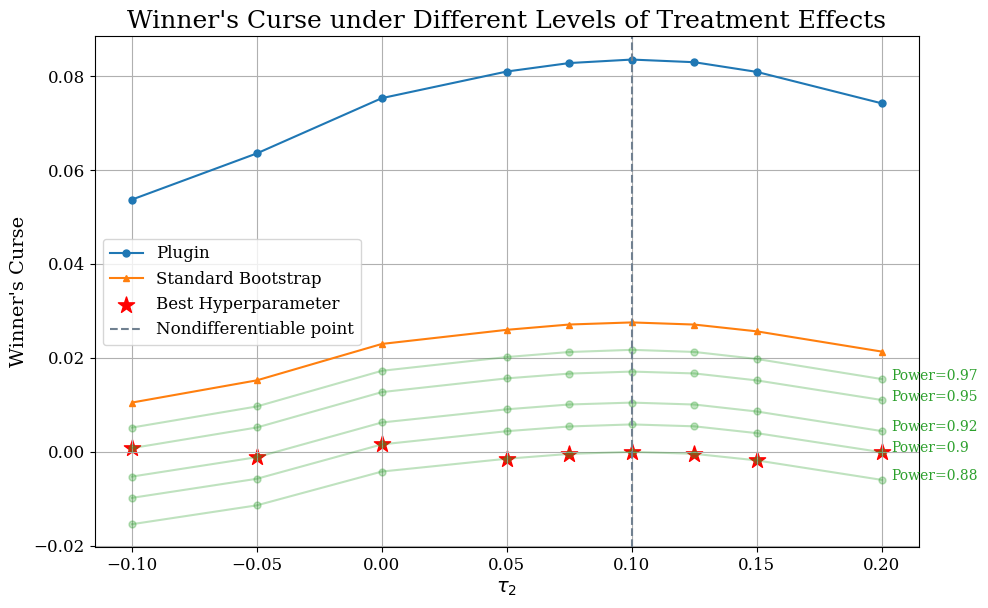

In [53]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['standard_bootstrap_mean'], '^-', markersize=5, label='Standard Bootstrap', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'mn_bootstrap_mean']]
    ax.plot(mnb_df['tau'], mnb_df['mn_bootstrap_mean'], 'o-', color='C2', alpha=0.3, markersize=5)
    ax.text(
        mnb_df['tau'].values[-1] * 1.02, mnb_df['mn_bootstrap_mean'].values[-1] * 0.99, 
        f'Power={power}', 
        fontsize=10, color='C2'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best Hyperparameter')

# plot the nondifferentiable point
ax.axvline(dgp_params['te_arr'][0], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel(r'$\tau_2$', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/ts-mnb-hyperparam-test.png')
plt.show()

In [56]:
operations_params = {}

dgp_params = {'te_arr': np.array([1, 1.1]), 'noise_std': 1, 'response_type': 'continuous'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 2000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 2000, 'bootstrap_method': 'm_out_of_n', 
            'power': np.nan,
        }
    }, 
}

tau_arr = np.arange(0.7, 0.99, 0.02)
tau_result_dict = {tau: {} for tau in tau_arr}

for tau in tqdm(tau_arr):
    estimators_dict['mn_bootstrap']['params']['power'] = tau

    result_record = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=False, n_jobs=-1
    )

    wc_measures_dict = ts.calculate_winners_curse_measures(
        result_records=result_record,
        estimators_dict=estimators_dict, data_params=data_params
    )

    tau_result_dict[tau] = {
        'nc_wc_avg': wc_measures_dict['nc_wc_avg'], 
        'nc_wc_se': wc_measures_dict['nc_wc_se'],
        'standard_bootstrap_wc_avg': wc_measures_dict['standard_bootstrap_wc_avg'], 
        'standard_bootstrap_wc_se': wc_measures_dict['standard_bootstrap_wc_se'],
        'mn_bootstrap_wc_avg': wc_measures_dict['mn_bootstrap_wc_avg'], 
        'mn_bootstrap_wc_se': wc_measures_dict['mn_bootstrap_wc_se'],
    }
tau_result_df = 100 * pd.DataFrame.from_dict(tau_result_dict, orient='index') / 0.1

100%|██████████| 15/15 [04:10<00:00, 16.68s/it]


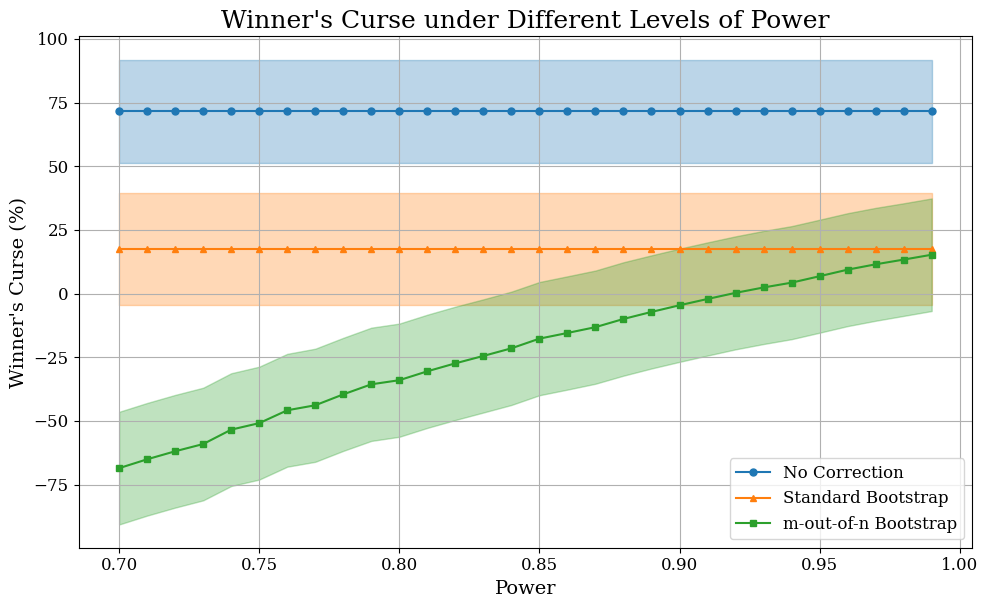

In [34]:
tau_result_df = 100 * pd.DataFrame.from_dict(tau_result_dict, orient='index') / 0.1

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.plot(tau_result_df.index, tau_result_df['nc_wc_avg'], 'o-', markersize=5, label='No Correction', color='C0')

ax.plot(tau_result_df.index, tau_result_df['standard_bootstrap_wc_avg'], '^-', markersize=5, label='Standard Bootstrap', color='C1')

ax.plot(tau_result_df.index, tau_result_df['mn_bootstrap_wc_avg'], 's-', markersize=5, label='m-out-of-n Bootstrap', color='C2')

ax.fill_between(
    tau_result_df.index, 
    tau_result_df['nc_wc_avg'] - 1.65 * tau_result_df['nc_wc_se'],
    tau_result_df['nc_wc_avg'] + 1.65 * tau_result_df['nc_wc_se'],
    color='C0', alpha=0.3
)

ax.fill_between(
    tau_result_df.index, 
    tau_result_df['standard_bootstrap_wc_avg'] - 1.65 * tau_result_df['standard_bootstrap_wc_se'],
    tau_result_df['standard_bootstrap_wc_avg'] + 1.65 * tau_result_df['standard_bootstrap_wc_se'],
    color='C1', alpha=0.3
)

ax.fill_between(
    tau_result_df.index, 
    tau_result_df['mn_bootstrap_wc_avg'] - 1.65 * tau_result_df['mn_bootstrap_wc_se'],
    tau_result_df['mn_bootstrap_wc_avg'] + 1.65 * tau_result_df['mn_bootstrap_wc_se'],
    color='C2', alpha=0.3
)

ax.set_title("Winner's Curse under Different Levels of Power", fontsize=title_size)
ax.set_xlabel(r'Power', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/ts-mnb-power-test.png')

### Numerical bootstrap

In [31]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': np.nan, 
        }
    }
}

In [ ]:
tau2_list = [-0.1, -0.05, 0, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2]
power_list = [-0.40, -0.41, -0.42, -0.43, -0.44, -0.45, -0.46, -0.47, -0.48, -0.49]
result_dict = {(tau2, power): None for tau2 in tau2_list for power in power_list}

for tau2 in tau2_list:
    dgp_params['te_arr'][1] = tau2
    for power in power_list: 
        print(f'Tau2 = {tau2}, Power = {power}')
        estimators_dict['num_bootstrap']['params']['power'] = power
        
        result_record = ts.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(tau2, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(tau2, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/ts_numb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [54]:
with open('results/ts_numb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

result_df = result_df[result_df['power'].isin([-0.40, -0.42, -0.44, -0.46, -0.48])]

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'standard_bootstrap_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'num_bootstrap_mean']]
    best_wc_list[idx] = temp['num_bootstrap_mean'].loc[(-temp['num_bootstrap_mean'].abs()).idxmax()]

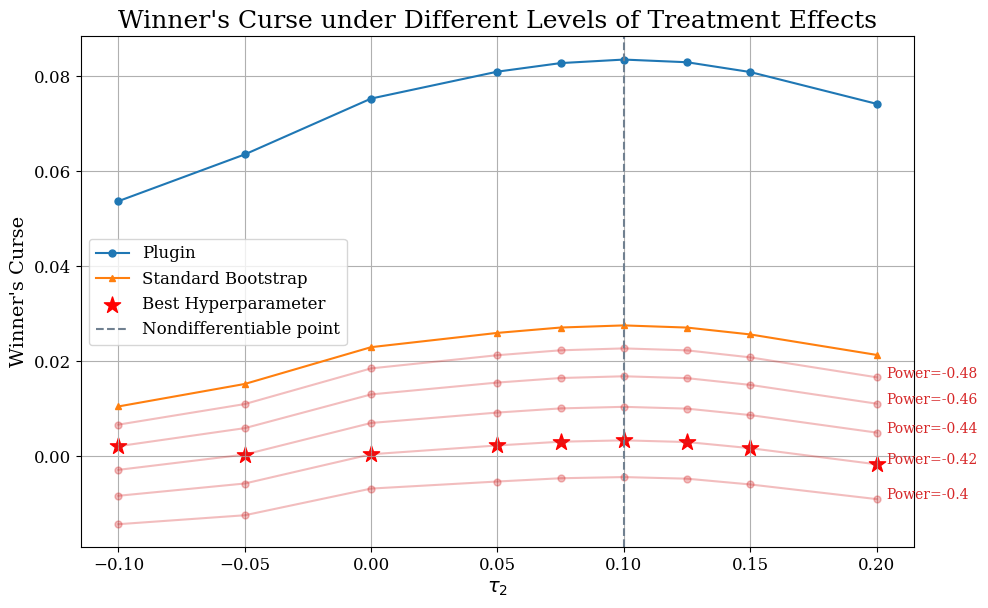

In [55]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['standard_bootstrap_mean'], '^-', markersize=5, label='Standard Bootstrap', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'num_bootstrap_mean']]
    ax.plot(mnb_df['tau'], mnb_df['num_bootstrap_mean'], 'o-', color='C3', alpha=0.3, markersize=5)
    ax.text(
        mnb_df['tau'].values[-1] * 1.02, mnb_df['num_bootstrap_mean'].values[-1] * 0.99, 
        f'Power={power}', 
        fontsize=10, color='C3'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best Hyperparameter')

# plot the nondifferentiable point
ax.axvline(dgp_params['te_arr'][0], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel(r'$\tau_2$', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/ts-numb-hyperparam-test.png')
plt.show()

In [57]:
operations_params = {}

dgp_params = {'te_arr': np.array([1, 1.1]), 'noise_std': 1, 'response_type': 'continuous'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': np.nan, 
        }
    }, 
}

power_arr = np.arange(-0.49, -0.3, 0.01)
power_result_dict = {power: {} for power in power_arr}

for power in tqdm(power_arr):
    estimators_dict['num_bootstrap']['params']['power'] = power

    result_record = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=False, n_jobs=-1
    )

    wc_measures_dict = ts.calculate_winners_curse_measures(
        result_records=result_record,
        estimators_dict=estimators_dict, data_params=data_params
    )

    power_result_dict[power] = {
        'nc_wc_avg': wc_measures_dict['nc_wc_avg'], 
        'nc_wc_se': wc_measures_dict['nc_wc_se'],
        'standard_bootstrap_wc_avg': wc_measures_dict['standard_bootstrap_wc_avg'], 
        'standard_bootstrap_wc_se': wc_measures_dict['standard_bootstrap_wc_se'],
        'num_bootstrap_wc_avg': wc_measures_dict['num_bootstrap_wc_avg'], 
        'num_bootstrap_wc_se': wc_measures_dict['num_bootstrap_wc_se'],
    }

power_result_df = 100 * pd.DataFrame.from_dict(power_result_dict, orient='index') / 0.1

100%|██████████| 19/19 [01:17<00:00,  4.10s/it]


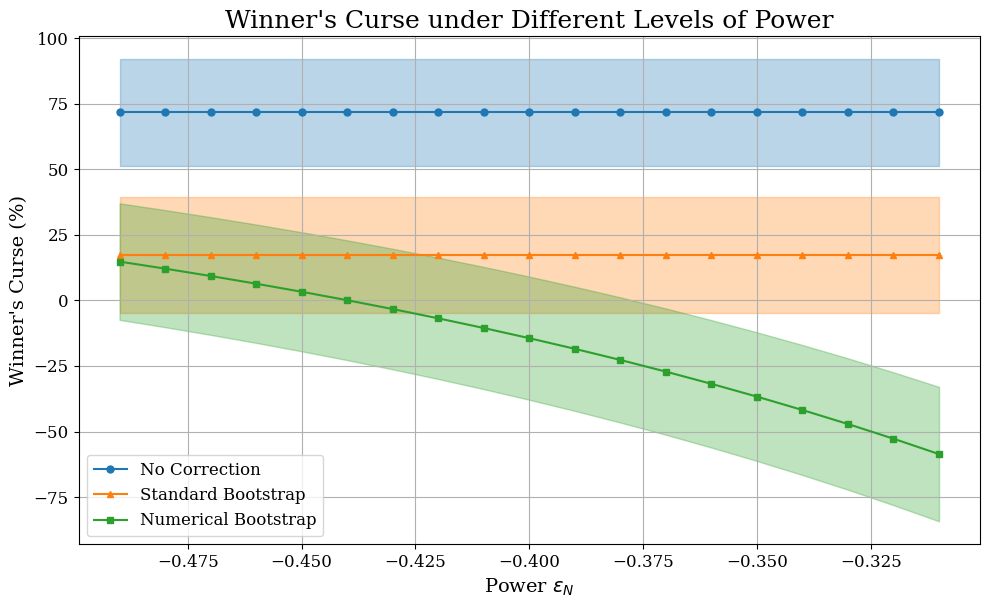

In [25]:
power_result_df = 100 * pd.DataFrame.from_dict(power_result_dict, orient='index') / 0.1

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.plot(power_result_df.index, power_result_df['nc_wc_avg'], 'o-', markersize=5, label='No Correction', color='C0')

ax.plot(power_result_df.index, power_result_df['standard_bootstrap_wc_avg'], '^-', markersize=5, label='Standard Bootstrap', color='C1')

ax.plot(power_result_df.index, power_result_df['num_bootstrap_wc_avg'], 's-', markersize=5, label='Numerical Bootstrap', color='C2')

ax.fill_between(
    power_result_df.index, 
    power_result_df['nc_wc_avg'] - 1.65 * power_result_df['nc_wc_se'],
    power_result_df['nc_wc_avg'] + 1.65 * power_result_df['nc_wc_se'],
    color='C0', alpha=0.3
)

ax.fill_between(
    power_result_df.index, 
    power_result_df['standard_bootstrap_wc_avg'] - 1.65 * power_result_df['standard_bootstrap_wc_se'],
    power_result_df['standard_bootstrap_wc_avg'] + 1.65 * power_result_df['standard_bootstrap_wc_se'],
    color='C1', alpha=0.3
)

ax.fill_between(
    power_result_df.index, 
    power_result_df['num_bootstrap_wc_avg'] - 1.65 * power_result_df['num_bootstrap_wc_se'],
    power_result_df['num_bootstrap_wc_avg'] + 1.65 * power_result_df['num_bootstrap_wc_se'],
    color='C2', alpha=0.3
)

ax.set_title("Winner's Curse under Different Levels of Power", fontsize=title_size)
ax.set_xlabel(r'Power $\epsilon_N$', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

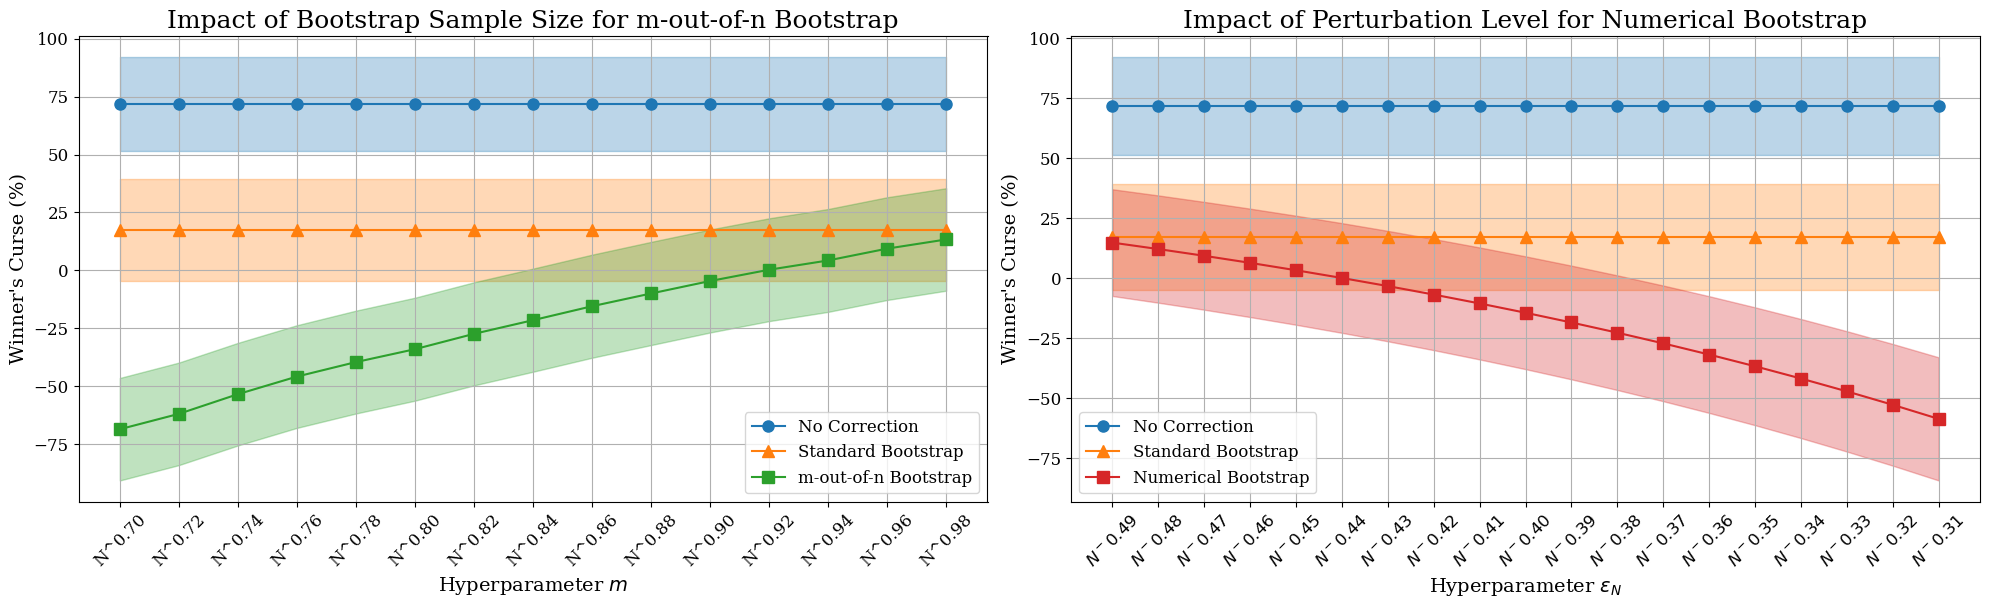

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

axes[0].plot(tau_result_df.index, tau_result_df['nc_wc_avg'], 'o-', markersize=8, label='No Correction', color='C0')

axes[0].plot(tau_result_df.index, tau_result_df['standard_bootstrap_wc_avg'], '^-', markersize=8, label='Standard Bootstrap', color='C1')

axes[0].plot(tau_result_df.index, tau_result_df['mn_bootstrap_wc_avg'], 's-', markersize=8, label='m-out-of-n Bootstrap', color='C2')

axes[0].fill_between(
    tau_result_df.index, 
    tau_result_df['nc_wc_avg'] - 1.65 * tau_result_df['nc_wc_se'],
    tau_result_df['nc_wc_avg'] + 1.65 * tau_result_df['nc_wc_se'],
    color='C0', alpha=0.3
)

axes[0].fill_between(
    tau_result_df.index, 
    tau_result_df['standard_bootstrap_wc_avg'] - 1.65 * tau_result_df['standard_bootstrap_wc_se'],
    tau_result_df['standard_bootstrap_wc_avg'] + 1.65 * tau_result_df['standard_bootstrap_wc_se'],
    color='C1', alpha=0.3
)

axes[0].fill_between(
    tau_result_df.index, 
    tau_result_df['mn_bootstrap_wc_avg'] - 1.65 * tau_result_df['mn_bootstrap_wc_se'],
    tau_result_df['mn_bootstrap_wc_avg'] + 1.65 * tau_result_df['mn_bootstrap_wc_se'],
    color='C2', alpha=0.3
)

axes[0].set_title("Impact of Bootstrap Sample Size for m-out-of-n Bootstrap", fontsize=title_size)
axes[0].set_xlabel(r'Hyperparameter $m$', fontsize=axis_label_size)
axes[0].set_xticks(tau_arr, [r'N^{:.2f}'.format(tau) for tau in tau_arr], rotation=45)
axes[0].set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
axes[0].legend(loc='best', fontsize=legend_label_size)
axes[0].tick_params(axis='both', which='major', labelsize=tick_label_size)
axes[0].grid()

axes[1].plot(power_result_df.index, power_result_df['nc_wc_avg'], 'o-', markersize=8, label='No Correction', color='C0')

axes[1].plot(power_result_df.index, power_result_df['standard_bootstrap_wc_avg'], '^-', markersize=8, label='Standard Bootstrap', color='C1')

axes[1].plot(power_result_df.index, power_result_df['num_bootstrap_wc_avg'], 's-', markersize=8, label='Numerical Bootstrap', color='C3')

axes[1].fill_between(
    power_result_df.index, 
    power_result_df['nc_wc_avg'] - 1.65 * power_result_df['nc_wc_se'],
    power_result_df['nc_wc_avg'] + 1.65 * power_result_df['nc_wc_se'],
    color='C0', alpha=0.3
)

axes[1].fill_between(
    power_result_df.index, 
    power_result_df['standard_bootstrap_wc_avg'] - 1.65 * power_result_df['standard_bootstrap_wc_se'],
    power_result_df['standard_bootstrap_wc_avg'] + 1.65 * power_result_df['standard_bootstrap_wc_se'],
    color='C1', alpha=0.3
)

axes[1].fill_between(
    power_result_df.index, 
    power_result_df['num_bootstrap_wc_avg'] - 1.65 * power_result_df['num_bootstrap_wc_se'],
    power_result_df['num_bootstrap_wc_avg'] + 1.65 * power_result_df['num_bootstrap_wc_se'],
    color='C3', alpha=0.3
)

axes[1].set_title("Impact of Perturbation Level for Numerical Bootstrap", fontsize=title_size)
axes[1].set_xlabel(r'Hyperparameter $\epsilon_N$', fontsize=axis_label_size)
axes[1].set_xticks(power_arr, [r'$N^{:.2f}$'.format(power) for power in power_arr], rotation=45)
axes[1].set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
axes[1].legend(loc='best', fontsize=legend_label_size)
axes[1].tick_params(axis='both', which='major', labelsize=tick_label_size)
axes[1].grid()

plt.tight_layout()
plt.show()

## Ratio test: te_diff / noise_std


In [24]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'noise_std': np.nan}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.88,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': -0.42,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [25]:
ratio_arr = np.array([0, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
noise_std = 1
te_diff = noise_std * ratio_arr

result_dict = {(te_diff, noise_std): None for te_diff in te_diff}

for te_diff in tqdm(te_diff):
    dgp_params['te_arr'][1] = dgp_params['te_arr'][0] + te_diff
    dgp_params['noise_std'] = noise_std
    result_dict[(te_diff, noise_std)] = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=False, n_jobs=-1
    )

for key in result_dict.keys():
    result_dict[key] = ts.calculate_winners_curse_measures(
        result_records=result_dict[key],
        estimators_dict=estimators_dict, data_params=data_params
    )

100%|██████████| 14/14 [02:46<00:00, 11.92s/it]


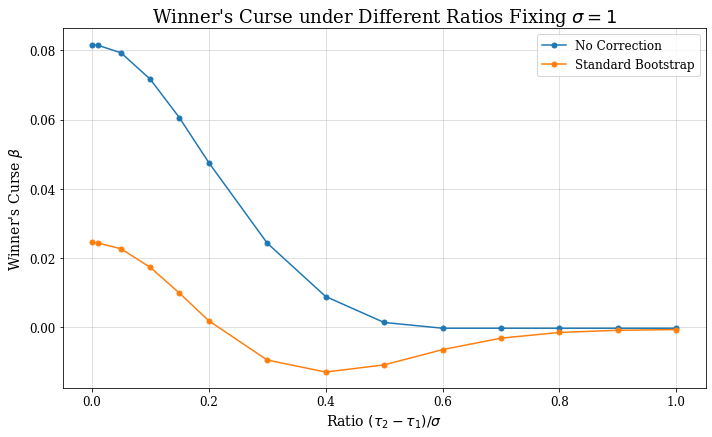

In [28]:
wc_avg_arr = np.array([result_dict[key]['nc_wc_avg'] for key in result_dict.keys()])
wc_se_arr = np.array([result_dict[key]['nc_wc_se'] for key in result_dict.keys()])

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plot winner's curse of no correction 
for idx, estimator in enumerate(['nc', 'standard_bootstrap']):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    wc_avg_arr = np.array([result_dict[key][f'{estimator}_wc_avg'] for key in result_dict.keys()])
    wc_se_arr = np.array([result_dict[key][f'{estimator}_wc_se'] for key in result_dict.keys()])
    ax.plot(ratio_arr, wc_avg_arr, 'o-', markersize=5, label=display_name, color=f'C{idx}')
    # ax.fill_between(ratio_arr, wc_avg_arr - 1.96 * wc_se_arr, wc_avg_arr + 1.96 * wc_se_arr, color=f'C{idx}', alpha=0.3)

ax.set_title(r"Winner's Curse under Different Ratios Fixing $\sigma={}$".format(noise_std), fontsize=title_size)
ax.set_xlabel(r'Ratio $(\tau_2 - \tau_1) / \sigma$', fontsize=axis_label_size)
ax.set_ylabel(r"Winner's Curse $\beta$", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [49]:
pd.DataFrame.from_dict({
    te_diff: {
        'nc_wc_avg': temp_dict['nc_wc_avg'] / te_diff, 
        'nc_wc_se': temp_dict['nc_wc_se'] / te_diff, 
        'standard_bootstrap_wc_avg': temp_dict['standard_bootstrap_wc_avg'] / te_diff,
        'standard_bootstrap_wc_se': temp_dict['standard_bootstrap_wc_se'] / te_diff,
    } for (te_diff, _), temp_dict in result_dict.items()
}).T

/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_71314/4110471864.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  'nc_wc_avg': temp_dict['nc_wc_avg'] / te_diff,
/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_71314/4110471864.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  'nc_wc_se': temp_dict['nc_wc_se'] / te_diff,
/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_71314/4110471864.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  'standard_bootstrap_wc_avg': temp_dict['standard_bootstrap_wc_avg'] / te_diff,
/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_71314/4110471864.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  'standard_bootstrap_wc_se': temp_dict['standard_bootstrap_wc_se'] / te_diff,


,nc_wc_avg,nc_wc_se,standard_bootstrap_wc_avg,standard_bootstrap_wc_se
0.00,inf,inf,inf,inf
0.01,8.152101,1.173852,2.435654,1.297737
0.05,1.585883,0.237621,0.452863,0.261554
0.10,0.716707,0.122599,0.172735,0.134218
0.15,0.403426,0.085858,0.065464,0.093341
0.20,0.237951,0.067550,0.009311,0.073251
0.30,0.080981,0.045397,-0.031693,0.049407
0.40,0.022122,0.034514,-0.032470,0.037402
0.50,0.002696,0.027483,-0.021835,0.029398
0.60,-0.000534,0.022762,-0.010856,0.023754


In [71]:
ratio = 0.1
noise_std_arr = np.array([0.1, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5])
te_diff_arr = noise_std_arr * ratio

result_dict = {(te_diff, noise_std): None for te_diff, noise_std in zip(te_diff_arr, noise_std_arr)}

for te_diff, noise_std in tqdm(zip(te_diff_arr, noise_std_arr)):
    dgp_params['te_arr'][1] = dgp_params['te_arr'][0] + te_diff
    dgp_params['noise_std'] = noise_std
    result_dict[(te_diff, noise_std)] = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=False, n_jobs=-1
    )

for key in result_dict.keys():
    result_dict[key] = ts.calculate_winners_curse_measures(
        result_records=result_dict[key],
        estimators_dict=estimators_dict, data_params=data_params
    )

9it [00:57,  6.35s/it]


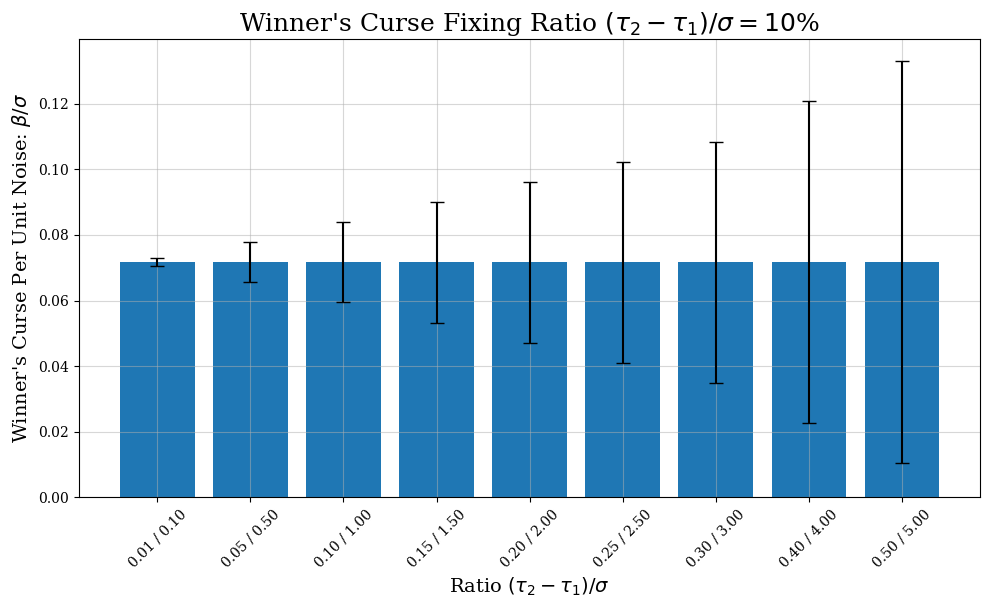

In [79]:
wc_avg_arr = np.array([result_dict[key]['nc_wc_avg'] for key in result_dict.keys()]) / noise_std_arr
wc_se_arr = np.array([result_dict[key]['nc_wc_se'] for key in result_dict.keys()])

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# plot winner's curse of no correction for each te_diff / noise_std pair
ax.bar(
    np.arange(len(wc_avg_arr)), wc_avg_arr, yerr=wc_se_arr, capsize=5, color='C0'
)

ax.set_title(r"Winner's Curse Fixing Ratio $(\tau_2 - \tau_1) / \sigma = {:.0f}$%".format(100 * ratio), fontsize=title_size)
ax.set_xlabel(r'Ratio $(\tau_2 - \tau_1) / \sigma$', fontsize=axis_label_size)
ax.set_ylabel(r"Winner's Curse Per Unit Noise: $\beta / \sigma$", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(wc_avg_arr)))
ax.set_xticklabels([f'{te_diff:.2f} / {noise_std:.2f}' for te_diff, noise_std in zip(te_diff_arr, noise_std_arr)], rotation=45)
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

## Sample size

In [30]:
for delta_tau in [0.05, 0.1, 0.5]:
    sample_sizes = np.array([100, 250, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000])

    operations_params = {}

    dgp_params = {'te_arr': np.array([1, 1.05]), 'noise_std': 1, 'response_type': 'continuous'}

    data_params = {'sample_size': np.nan}

    experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

    estimators_dict = {
        'standard_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'standard',
            }, 
            'display_name': 'Standard Bootstrap'
        }, 
        'mn_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
                'power': 0.95,
            }, 
            'display_name': 'm-out-of-n Bootstrap'
        }, 
        'num_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
                'power': - 0.45,
            }, 
            'display_name': 'Numerical Bootstrap'
        }, 
    }

    result_dict = {sample_size: None for sample_size in sample_sizes}

    for sample_size in tqdm(sample_sizes):
        data_params['sample_size'] = int(sample_size)
        result_dict[sample_size] = ts.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=False, n_jobs=-1
        )

    for key in result_dict.keys():
        result_dict[key] = ts.calculate_winners_curse_measures(
            result_records=result_dict[key],
            estimators_dict=estimators_dict, data_params=data_params
        )

    # save results
    with open(f'results/tsss_sample_size_{delta_tau}.pkl', 'wb') as f:
        pickle.dump(result_dict, f)

100%|██████████| 12/12 [32:38<00:00, 163.24s/it]


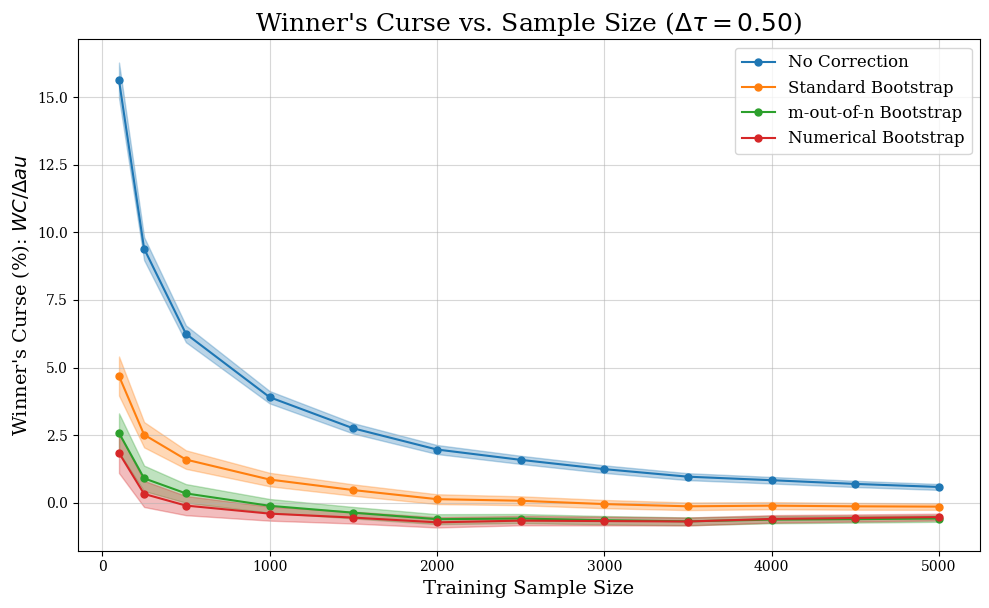

In [38]:
delta_tau = 0.5
estimators_viz_list = ['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']

with open(f'results/tsss_sample_size_{delta_tau}.pkl', 'rb') as f:
    result_dict = pickle.load(f)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

width = 0.2

# plot winner's curse of no correction for each te_diff / noise_std pair
plot_list = [None] * len(estimators_viz_list)
for idx, estimator in enumerate(estimators_viz_list):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    wc_avg_arr = 100 * np.array([result_dict[key][f'{estimator}_wc_avg'] for key in result_dict.keys()]) / delta_tau
    wc_se_arr = 100 * np.array([result_dict[key][f'{estimator}_wc_se'] for key in result_dict.keys()]) / delta_tau
    # ax.bar(
    #     np.arange(len(wc_avg_arr)) + (idx - 1.5) * width, wc_avg_arr, yerr=wc_se_arr, capsize=5, color=f'C{idx}', alpha=0.75, width=width
    # )
    plot_list[idx], = ax.plot(sample_sizes, wc_avg_arr, 'o-', markersize=5, label=display_name, color=f'C{idx}')
    
    ax.fill_between(sample_sizes, wc_avg_arr - 1.96 * wc_se_arr, wc_avg_arr + 1.96 * wc_se_arr, color=f'C{idx}', alpha=0.3)

ax.set_title(r"Winner's Curse vs. Sample Size ($\Delta\tau={:.2f}$)".format(delta_tau), fontsize=title_size)
ax.set_xlabel('Training Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse (%): $WC/\Delta\tau$", fontsize=axis_label_size)
# ax.set_xticks(sample_sizes)
# ax.set_xticklabels(sample_sizes, rotation=45)
ax.grid(True, alpha=0.5)
ax.legend(handles=plot_list, loc='best', fontsize=legend_label_size)

plt.tight_layout()
plt.show()

In [ ]:
operations_params = {}

dgp_params = {'te_arr': np.array([1, 1.1]), 'noise_std': 1, 'response_type': 'continuous'}

data_params = {'sample_size': np.nan}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

estimators_dict = {
    'sample_splitting': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {}, 
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }, 
        'display_name': 'Numerical Bootstrap'
    }, 
}

In [ ]:
sample_sizes = np.array([100, 200, 300, 400, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000])

result_dict = {sample_size: None for sample_size in sample_sizes}

for sample_size in tqdm(sample_sizes):
    data_params['sample_size'] = int(sample_size)
    result_dict[sample_size] = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=False, n_jobs=-1
    )

for key in result_dict.keys():
    result_dict[key] = ts.calculate_winners_curse_measures(
        result_records=result_dict[key],
        estimators_dict=estimators_dict, data_params=data_params
    )

  7%|▋         | 1/14 [00:41<08:55, 41.22s/it]


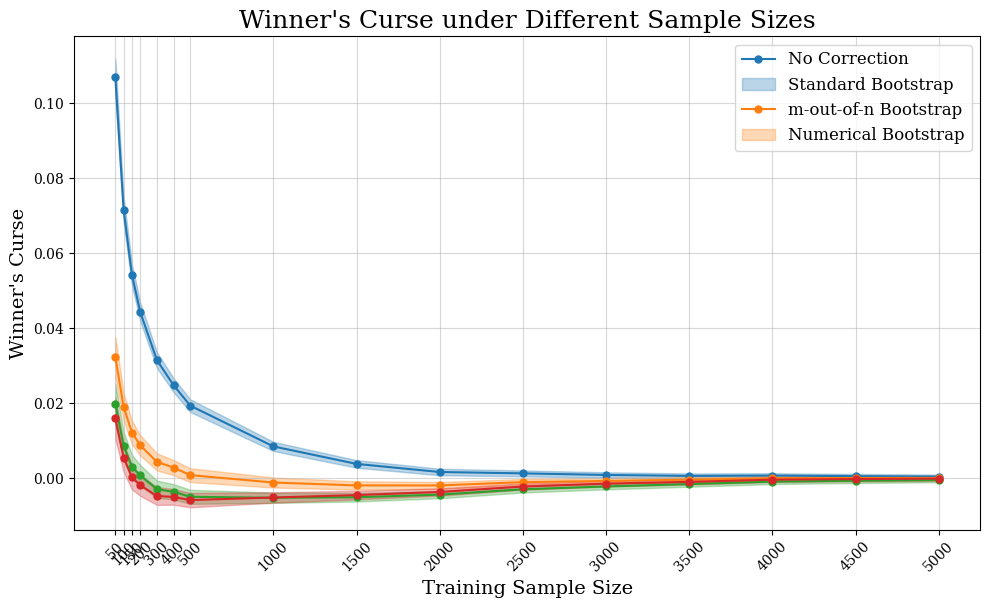

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

width = 0.2

# plot winner's curse of no correction for each te_diff / noise_std pair
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):

    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    wc_avg_arr = np.array([result_dict[key][f'{estimator}_wc_avg'] for key in result_dict.keys()])
    wc_se_arr = np.array([result_dict[key][f'{estimator}_wc_se'] for key in result_dict.keys()])
    # ax.bar(
    #     np.arange(len(wc_avg_arr)) + (idx - 1.5) * width, wc_avg_arr, yerr=wc_se_arr, capsize=5, color=f'C{idx}', alpha=0.75, width=width
    # )
    ax.plot(sample_sizes, wc_avg_arr, 'o-', markersize=5, label=display_name, color=f'C{idx}')
    ax.fill_between(sample_sizes, wc_avg_arr - 1.96 * wc_se_arr, wc_avg_arr + 1.96 * wc_se_arr, color=f'C{idx}', alpha=0.3)

ax.set_title("Winner's Curse under Different Sample Sizes", fontsize=title_size)
ax.set_xlabel('Training Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
# ax.set_xticks(sample_sizes)
# ax.set_xticklabels(sample_sizes, rotation=45)
ax.grid(True, alpha=0.5)
ax.legend(['No Correction'] + [estimators_dict[estimator]['display_name'] for estimator in ['standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']], fontsize=legend_label_size)

plt.tight_layout()
plt.show()

# Bernoulli Response

In [20]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.11]), 'response_type': 'bernoulli'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

estimators_dict = {
    'sample_splitting': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {}, 
        'display_name': 'Sample Splitting'
    }, 
    'cross_validation': {
        'estimator': ts.cross_validation_estimate,
        'params': {'n_splits': 5},
        'display_name': 'Cross Validation'
    }, 
    # 'empirical_bayes': {
    #     'estimator': ts.empirical_bayes_estimate, 
    #     'params': {'dof': 3, 'bin_width': 0.2}, 
    #     'display_name': 'Empirical Bayes \nEfron 2011, JASA'
    # }, 
    'normal_prior_bayes': {
        'estimator': ts.normal_prior_bayes_estimate, 
        'params': {'prior_mean': 0, 'prior_std': 1}, 
        'display_name': 'Normal Prior Bayes \nKessler 2024, Amazon'
    }, 
    'conditional_selective_inference':{
        'estimator': ts.conditional_selective_inference,
        'params': {'quantile': 0.5}, 
        'display_name': 'Andrews et al. 2024, QJE'
    }, 
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [21]:
result_records = ts.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = ts.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 1408 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 2308 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Done 3408 tasks      | elapsed:   21.9s
[Parallel(n_jobs=-1)]: Done 4708 tasks      | elapsed:   30.5s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   32.3s finished


In [22]:
wc_dict = {}
delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            # 'wc_pct_avg': wc_measures_dict[f'{estimator}_wc_pct_avg'], 'wc_pct_se': wc_measures_dict[f'{estimator}_wc_pct_se'],
            # 'wc_rmse': wc_measures_dict[f'{estimator}_wc_rmse']
            "Median Winner's Curse (%)": 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            "Correct Decision Rate (%)": 100 * wc_measures_dict[f'{estimator}_correct_decision_rate']
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 

print("Overestimated Purchase Probability Lift: ")
wc_df.round(2)

Overestimated Purchase Probability Lift: 


,Avg. Winner's Curse (%),S.E. Winner's Curse (%),Median Winner's Curse (%),Correct Decision Rate (%)
No Correction,236.96,38.39,220.75,56.02
Sample Splitting,-16.10,61.09,-65.52,53.28
Cross Validation,-10.11,53.70,-41.13,56.44
"Normal Prior Bayes \nKessler 2024, Amazon",233.84,38.22,217.90,56.02
"Andrews et al. 2024, QJE",-427.39,217.81,-59.88,56.02
Standard Bootstrap,69.88,40.23,33.96,56.02
m-out-of-n Bootstrap,38.06,39.99,1.98,56.02
Numerical Bootstrap,25.97,40.84,-17.03,56.02


# Logit Model

In [10]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.3, 0.4]), 'response_type': 'logit'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

estimators_dict = {
    'sample_splitting': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {}, 
        'display_name': 'Sample Splitting'
    }, 
    'cross_validation': {
        'estimator': ts.cross_validation_estimate,
        'params': {'n_splits': 5},
        'display_name': 'Cross Validation'
    }, 
    # 'empirical_bayes': {
    #     'estimator': ts.empirical_bayes_estimate, 
    #     'params': {'dof': 3, 'bin_width': 0.2}, 
    #     'display_name': 'Empirical Bayes \nEfron 2011, JASA'
    # }, 
    'normal_prior_bayes': {
        'estimator': ts.normal_prior_bayes_estimate, 
        'params': {'prior_mean': 0, 'prior_std': 1}, 
        'display_name': 'Normal Prior Bayes \nKessler 2024, Amazon'
    }, 
    'conditional_selective_inference':{
        'estimator': ts.conditional_selective_inference,
        'params': {'quantile': 0.5}, 
        'display_name': 'Andrews et al. 2024, QJE'
    }, 
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [11]:
result_records = ts.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = ts.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   24.5s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   46.0s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  4.1min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  5.1min finished


In [12]:
wc_dict = {}
delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            # 'wc_pct_avg': wc_measures_dict[f'{estimator}_wc_pct_avg'], 'wc_pct_se': wc_measures_dict[f'{estimator}_wc_pct_se'],
            # 'wc_rmse': wc_measures_dict[f'{estimator}_wc_rmse']
            "Median Winner's Curse (%)": 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            "Correct Decision Rate (%)": 100 * wc_measures_dict[f'{estimator}_correct_decision_rate']
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 

print("Overestimated Purchase Probability Lift: ")
wc_df.round(2)

Overestimated Purchase Probability Lift: 


,Avg. Winner's Curse (%),S.E. Winner's Curse (%),Median Winner's Curse (%),Correct Decision Rate (%)
No Correction,167.19,25.71,156.76,60.20
Sample Splitting,6.50,43.48,-12.32,55.86
Cross Validation,147.18,76.01,53.74,59.72
"Normal Prior Bayes \nKessler 2024, Amazon",164.81,25.61,154.55,60.20
"Andrews et al. 2024, QJE",-6007.87,13759.87,143.62,60.20
Standard Bootstrap,38.94,27.63,21.33,60.20
m-out-of-n Bootstrap,12.34,27.44,-6.30,60.20
Numerical Bootstrap,5.51,28.16,-13.33,60.20


# Hold-out Analysis

## Continuous response

In [11]:
operations_params = {}

dgp_params = {'te_arr': np.array([1, 1.5]), 'noise_std': 1, 'response_type': 'continuous'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

estimators_dict = {
    'sample_splitting_50': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.5}, 
        'display_name': 'Sample Splitting 50%'
    }, 
    'sample_splitting_40': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.4}, 
        'display_name': 'Sample Splitting 40%'
    }, 
    'sample_splitting_30': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.3}, 
        'display_name': 'Sample Splitting 30%'
    }, 
    'sample_splitting_20': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.2}, 
        'display_name': 'Sample Splitting 20%'
    }, 
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }, 
        'display_name': 'Numerical Bootstrap'
    }, 
}

result_records = ts.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = ts.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   23.5s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   32.4s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:   42.7s
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:   54.5s
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  1.1min finished


In [12]:
wc_dict = {}
delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    if f'{estimator}_val_true_avg' in wc_measures_dict.keys():
        avg_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_avg']
        se_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_se']
    else: 
        avg_estimator_val_true = wc_measures_dict['nc_val_true_avg']
        se_estimator_val_true = wc_measures_dict['nc_val_true_se']

    wc_dict.update({
        display_name: {
            "Winner's Curse (%) Avg.": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "Winner's Curse (%) S.E.": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            'Correct Decision Rate (%)': 100 * wc_measures_dict[f'{estimator}_correct_decision_rate'], 
            'True Policy Value Avg.': avg_estimator_val_true,
            'True Policy Value S.E.': se_estimator_val_true, 
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 
print("Overestimated Profit Lift: ")
wc_df.round(4)

Overestimated Profit Lift: 


,Winner's Curse (%) Avg.,Winner's Curse (%) S.E.,Median Winner's Curse (%),Correct Decision Rate (%),True Policy Value Avg.,True Policy Value S.E.
No Correction,-0.0186,2.8434,-0.2436,99.50,1.4975,0.0035
Sample Splitting 50%,-5.0862,4.4477,-3.5319,95.78,1.4789,0.0101
Sample Splitting 40%,-3.2372,4.7723,-1.7807,97.24,1.4862,0.0082
Sample Splitting 30%,-2.2331,5.4208,-1.8352,97.84,1.4892,0.0073
Sample Splitting 20%,-2.3213,6.7604,-2.0035,98.78,1.4939,0.0055
Standard Bootstrap,-2.4829,3.0537,-1.5447,99.50,1.4975,0.0035
m-out-of-n Bootstrap,-3.5330,3.1124,-2.4432,99.50,1.4975,0.0035
Numerical Bootstrap,-3.1086,3.1127,-1.8036,99.50,1.4975,0.0035


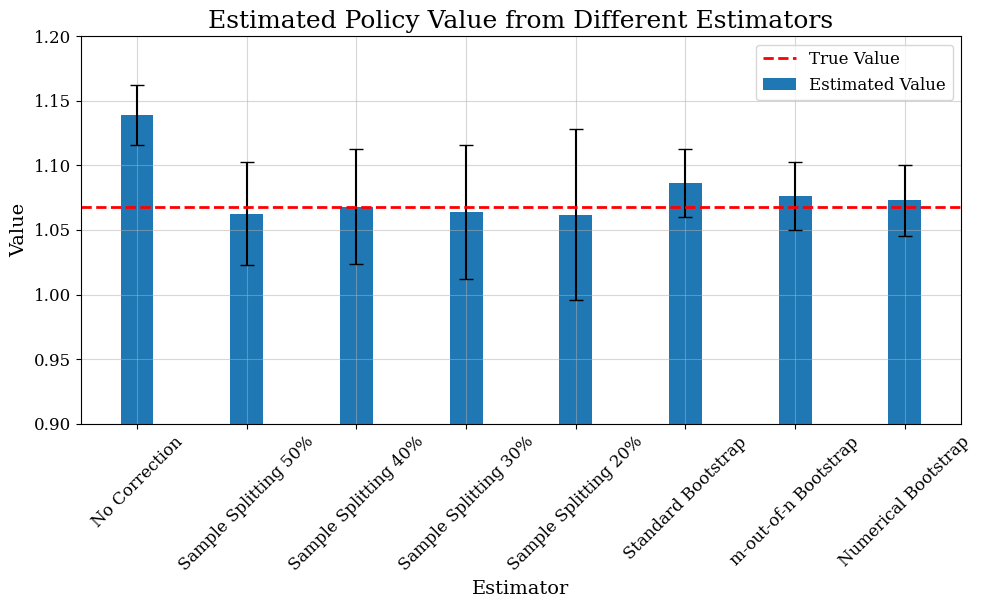

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

viz_estimators_list = ['nc'] + list(estimators_dict.keys())
avg_est_list = [
    wc_measures_dict[f'{estimator}_val_est_avg'] if f'{estimator}_val_est_avg' in wc_measures_dict.keys() else wc_measures_dict['nc_val_est_avg']
    for estimator in viz_estimators_list 
]
se_est_list = [
    wc_measures_dict[f'{estimator}_val_est_se'] if f'{estimator}_val_est_se' in wc_measures_dict.keys() else wc_measures_dict['nc_val_est_se']
    for estimator in viz_estimators_list 
]

ax.bar(
    x=np.arange(len(viz_estimators_list)), 
    height=avg_est_list, 
    yerr=[1.96 * se for se in se_est_list],
    capsize=5, color='C0', width=0.3
)

ax.axhline(wc_measures_dict['nc_val_true_avg'], color='red', linestyle='--', linewidth=2)

ax.set_title("Estimated Policy Value from Different Estimators", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(viz_estimators_list)))
ax.set_xticklabels(['No Correction'] + [estimators_dict[estimator]['display_name'] for estimator in viz_estimators_list[1:]], rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

ax.set_ylim([0.9, 1.2])

ax.legend(['True Value', 'Estimated Value'], fontsize=legend_label_size)

ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [10]:
for delta_tau in [0.05, 0.1, 0.5]:
    print(f'\n\nDelta Tau: {delta_tau}: ')
    
    operations_params = {}

    dgp_params = {'te_arr': np.array([1, 1 + delta_tau]), 'noise_std': 1, 'response_type': 'continuous'}

    data_params = {'sample_size': 100}

    experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

    estimators_dict = {
        'sample_splitting_50': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.5}, 
            'display_name': 'Sample Splitting 50%'
        }, 
        'sample_splitting_40': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.4}, 
            'display_name': 'Sample Splitting 40%'
        }, 
        'sample_splitting_30': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.3}, 
            'display_name': 'Sample Splitting 30%'
        }, 
        'sample_splitting_20': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.2}, 
            'display_name': 'Sample Splitting 20%'
        }, 
        # 'standard_bootstrap': {
        #     'estimator': ts.bootstrap_correction_estimate, 
        #     'params': {
        #         'n_bootstraps': 500, 'bootstrap_method': 'standard',
        #     }, 
        #     'display_name': 'Standard Bootstrap'
        # }, 
        # 'mn_bootstrap': {
        #     'estimator': ts.bootstrap_correction_estimate, 
        #     'params': {
        #         'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
        #         'power': 0.95,
        #     }, 
        #     'display_name': 'm-out-of-n Bootstrap'
        # }, 
        # 'num_bootstrap': {
        #     'estimator': ts.bootstrap_correction_estimate, 
        #     'params': {
        #         'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
        #         'power': - 0.45,
        #     }, 
        #     'display_name': 'Numerical Bootstrap'
        # }, 
    }

    result_records = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, n_jobs=-1
    )

    wc_measures_dict = ts.calculate_winners_curse_measures(
        result_records=result_records,
        estimators_dict=estimators_dict, data_params=data_params
    )

    wc_dict = {}
    delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
    for estimator in ['nc'] + list(estimators_dict.keys()):
        display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

        if f'{estimator}_val_true_avg' in wc_measures_dict.keys():
            avg_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_avg']
            se_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_se']
        else: 
            avg_estimator_val_true = wc_measures_dict['nc_val_true_avg']
            se_estimator_val_true = wc_measures_dict['nc_val_true_se']

        wc_dict.update({
            display_name: {
                # "Winner's Curse (%) Avg.": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
                # "Winner's Curse (%) S.E.": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
                # 'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
                'Correct Decision Rate (%)': 100 * wc_measures_dict[f'{estimator}_correct_decision_rate'], 
                'True Policy Value Avg.': avg_estimator_val_true,
                'True Policy Value S.E.': se_estimator_val_true, 
            }
        })

    wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
    del wc_dict 
    print("Overestimated Profit Lift: ")
    print(wc_df.round(4))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s




Delta Tau: 0.05: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 3748 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s


Overestimated Profit Lift: 
                      Correct Decision Rate (%)  True Policy Value Avg.  \
No Correction                             58.62                  1.0293   
Sample Splitting 50%                      57.18                  1.0286   
Sample Splitting 40%                      56.90                  1.0284   
Sample Splitting 30%                      57.56                  1.0288   
Sample Splitting 20%                      57.20                  1.0286   

                      True Policy Value S.E.  
No Correction                         0.0025  
Sample Splitting 50%                  0.0025  
Sample Splitting 40%                  0.0025  
Sample Splitting 30%                  0.0025  
Sample Splitting 20%                  0.0025  


Delta Tau: 0.1: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 3777 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s


Overestimated Profit Lift: 
                      Correct Decision Rate (%)  True Policy Value Avg.  \
No Correction                             67.48                  1.0675   
Sample Splitting 50%                      63.98                  1.0640   
Sample Splitting 40%                      64.16                  1.0642   
Sample Splitting 30%                      65.36                  1.0654   
Sample Splitting 20%                      65.38                  1.0654   

                      True Policy Value S.E.  
No Correction                         0.0047  
Sample Splitting 50%                  0.0048  
Sample Splitting 40%                  0.0048  
Sample Splitting 30%                  0.0048  
Sample Splitting 20%                  0.0048  


Delta Tau: 0.5: 
Running 5000 experiments...
Overestimated Profit Lift: 
                      Correct Decision Rate (%)  True Policy Value Avg.  \
No Correction                             99.50                  1.4975   
Sample Splitti

[Parallel(n_jobs=-1)]: Done 3777 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished


## Bernoulli response

In [13]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.11]), 'noise_std': 1, 'response_type': 'bernoulli'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

estimators_dict = {
    'sample_splitting_50': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.5}, 
        'display_name': 'Sample Splitting 50%'
    }, 
    'sample_splitting_40': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.4}, 
        'display_name': 'Sample Splitting 40%'
    }, 
    'sample_splitting_30': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.3}, 
        'display_name': 'Sample Splitting 30%'
    }, 
    'sample_splitting_20': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.2}, 
        'display_name': 'Sample Splitting 20%'
    }, 
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }, 
        'display_name': 'Numerical Bootstrap'
    }, 
}

result_records = ts.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = ts.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   16.1s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   23.7s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   32.7s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:   43.1s
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:   54.9s
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  1.1min finished


In [14]:
wc_dict = {}
delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    if f'{estimator}_val_true_avg' in wc_measures_dict.keys():
        avg_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_avg']
        se_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_se']
    else: 
        avg_estimator_val_true = wc_measures_dict['nc_val_true_avg']
        se_estimator_val_true = wc_measures_dict['nc_val_true_se']

    wc_dict.update({
        display_name: {
            "Winner's Curse (%) Avg.": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "Winner's Curse (%) S.E.": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            'Correct Decision Rate (%)': 100 * wc_measures_dict[f'{estimator}_correct_decision_rate'], 
            'True Policy Value Avg.': avg_estimator_val_true,
            'True Policy Value S.E.': se_estimator_val_true, 
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 
print("Overestimated Profit Lift: ")
wc_df.round(4)

Overestimated Profit Lift: 


,Winner's Curse (%) Avg.,Winner's Curse (%) S.E.,Median Winner's Curse (%),Correct Decision Rate (%),True Policy Value Avg.,True Policy Value S.E.
No Correction,236.9606,38.3891,220.7547,56.02,0.1056,0.0005
Sample Splitting 50%,-18.8403,61.5005,-65.5172,53.28,0.1053,0.0005
Sample Splitting 40%,-11.1352,70.3507,-47.6190,54.18,0.1054,0.0005
Sample Splitting 30%,-5.9076,81.4228,-147.6190,54.44,0.1054,0.0005
Sample Splitting 20%,5.7752,101.3172,-90.9091,55.98,0.1056,0.0005
Standard Bootstrap,69.8072,40.1758,32.8622,56.02,0.1056,0.0005
m-out-of-n Bootstrap,38.1505,39.9908,0.2462,56.02,0.1056,0.0005
Numerical Bootstrap,26.0873,40.9127,-17.5753,56.02,0.1056,0.0005


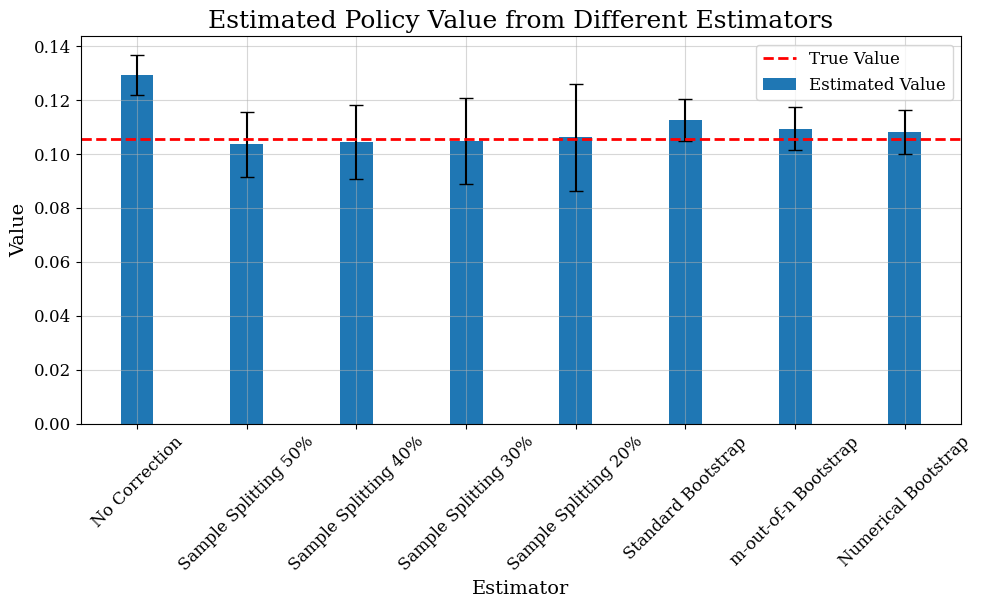

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

viz_estimators_list = ['nc'] + list(estimators_dict.keys())
avg_est_list = [
    wc_measures_dict[f'{estimator}_val_est_avg'] if f'{estimator}_val_est_avg' in wc_measures_dict.keys() else wc_measures_dict['nc_val_est_avg']
    for estimator in viz_estimators_list 
]
se_est_list = [
    wc_measures_dict[f'{estimator}_val_est_se'] if f'{estimator}_val_est_se' in wc_measures_dict.keys() else wc_measures_dict['nc_val_est_se']
    for estimator in viz_estimators_list 
]

ax.bar(
    x=np.arange(len(viz_estimators_list)), 
    height=avg_est_list, 
    yerr=[1.96 * se for se in se_est_list],
    capsize=5, color='C0', width=0.3
)

ax.axhline(wc_measures_dict['nc_val_true_avg'], color='red', linestyle='--', linewidth=2)

ax.set_title("Estimated Policy Value from Different Estimators", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(viz_estimators_list)))
ax.set_xticklabels(['No Correction'] + [estimators_dict[estimator]['display_name'] for estimator in viz_estimators_list[1:]], rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

# ax.set_ylim([0.9, 1.2])

ax.legend(['True Value', 'Estimated Value'], fontsize=legend_label_size)

ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [11]:
for te_arr in [[0.01, 0.011], [0.1, 0.11], [0.1, 0.15], [0.1, 0.2], [0.3, 0.4], [0.5, 0.6]]:
    print(f'\n\nTE arr: {te_arr}: ')
    
    operations_params = {}

    dgp_params = {'te_arr': np.array(te_arr), 'noise_std': 1, 'response_type': 'bernoulli'}

    data_params = {'sample_size': 100}

    experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

    estimators_dict = {
        'sample_splitting_50': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.5}, 
            'display_name': 'Sample Splitting 50%'
        }, 
        'sample_splitting_40': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.4}, 
            'display_name': 'Sample Splitting 40%'
        }, 
        'sample_splitting_30': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.3}, 
            'display_name': 'Sample Splitting 30%'
        }, 
        'sample_splitting_20': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.2}, 
            'display_name': 'Sample Splitting 20%'
        }, 
        # 'standard_bootstrap': {
        #     'estimator': ts.bootstrap_correction_estimate, 
        #     'params': {
        #         'n_bootstraps': 500, 'bootstrap_method': 'standard',
        #     }, 
        #     'display_name': 'Standard Bootstrap'
        # }, 
        # 'mn_bootstrap': {
        #     'estimator': ts.bootstrap_correction_estimate, 
        #     'params': {
        #         'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
        #         'power': 0.95,
        #     }, 
        #     'display_name': 'm-out-of-n Bootstrap'
        # }, 
        # 'num_bootstrap': {
        #     'estimator': ts.bootstrap_correction_estimate, 
        #     'params': {
        #         'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
        #         'power': - 0.45,
        #     }, 
        #     'display_name': 'Numerical Bootstrap'
        # }, 
    }

    result_records = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, n_jobs=-1
    )

    wc_measures_dict = ts.calculate_winners_curse_measures(
        result_records=result_records,
        estimators_dict=estimators_dict, data_params=data_params
    )

    wc_dict = {}
    delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
    for estimator in ['nc'] + list(estimators_dict.keys()):
        display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

        if f'{estimator}_val_true_avg' in wc_measures_dict.keys():
            avg_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_avg']
            se_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_se']
        else: 
            avg_estimator_val_true = wc_measures_dict['nc_val_true_avg']
            se_estimator_val_true = wc_measures_dict['nc_val_true_se']

        wc_dict.update({
            display_name: {
                # "Winner's Curse (%) Avg.": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
                # "Winner's Curse (%) S.E.": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
                # 'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
                'Correct Decision Rate (%)': 100 * wc_measures_dict[f'{estimator}_correct_decision_rate'], 
                'True Policy Value Avg.': avg_estimator_val_true,
                'True Policy Value S.E.': se_estimator_val_true, 
            }
        })

    wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
    del wc_dict 
    print("Overestimated Profit Lift: ")
    print(wc_df.round(4))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s




TE arr: [0.01, 0.011]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 3719 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s


Overestimated Profit Lift: 
                      Correct Decision Rate (%)  True Policy Value Avg.  \
No Correction                             33.72                  0.0103   
Sample Splitting 50%                      22.06                  0.0102   
Sample Splitting 40%                      24.50                  0.0102   
Sample Splitting 30%                      26.82                  0.0103   
Sample Splitting 20%                      29.56                  0.0103   

                      True Policy Value S.E.  
No Correction                            0.0  
Sample Splitting 50%                     0.0  
Sample Splitting 40%                     0.0  
Sample Splitting 30%                     0.0  
Sample Splitting 20%                     0.0  


TE arr: [0.1, 0.11]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 3748 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s


...

[Parallel(n_jobs=-1)]: Done 3777 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Correct Decision Rate (%)  True Policy Value Avg.  \
No Correction                             85.62                  0.3856   
Sample Splitting 50%                      76.08                  0.3761   
Sample Splitting 40%                      78.28                  0.3783   
Sample Splitting 30%                      80.90                  0.3809   
Sample Splitting 20%                      82.80                  0.3828   

                      True Policy Value S.E.  
No Correction                         0.0035  
Sample Splitting 50%                  0.0043  
Sample Splitting 40%                  0.0041  
Sample Splitting 30%                  0.0039  
Sample Splitting 20%                  0.0038  


TE arr: [0.5, 0.6]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 3777 tasks      | elapsed:    0.1s


Overestimated Profit Lift: 
                      Correct Decision Rate (%)  True Policy Value Avg.  \
No Correction                             83.92                  0.5839   
Sample Splitting 50%                      75.50                  0.5755   
Sample Splitting 40%                      77.62                  0.5776   
Sample Splitting 30%                      78.94                  0.5789   
Sample Splitting 20%                      80.50                  0.5805   

                      True Policy Value S.E.  
No Correction                         0.0037  
Sample Splitting 50%                  0.0043  
Sample Splitting 40%                  0.0042  
Sample Splitting 30%                  0.0041  
Sample Splitting 20%                  0.0040  


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished


## Logit response

In [48]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.2]), 'noise_std': 1, 'response_type': 'logit'}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

estimators_dict = {
    'sample_splitting_50': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.5}, 
        'display_name': 'Sample Splitting 50%'
    }, 
    'sample_splitting_40': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.4}, 
        'display_name': 'Sample Splitting 40%'
    }, 
    'sample_splitting_30': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.3}, 
        'display_name': 'Sample Splitting 30%'
    }, 
    'sample_splitting_20': {
        'estimator': ts.sample_splitting_estimate, 
        'params': {'hold_out_size': 0.2}, 
        'display_name': 'Sample Splitting 20%'
    }, 
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45,
        }, 
        'display_name': 'Numerical Bootstrap'
    }, 
}

result_records = ts.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = ts.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   11.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   47.0s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  4.9min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  5.0min finished


In [49]:
wc_dict = {}
delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    if f'{estimator}_val_true_avg' in wc_measures_dict.keys():
        avg_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_avg']
        se_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_se']
    else: 
        avg_estimator_val_true = wc_measures_dict['nc_val_true_avg']
        se_estimator_val_true = wc_measures_dict['nc_val_true_se']

    wc_dict.update({
        display_name: {
            "Winner's Curse (%) Avg.": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "Winner's Curse (%) S.E.": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            'Correct Decision Rate (%)': 100 * wc_measures_dict[f'{estimator}_correct_decision_rate'], 
            'True Policy Value Avg.': avg_estimator_val_true,
            'True Policy Value S.E.': se_estimator_val_true, 
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 
print("Overestimated Profit Lift: ")
wc_df.round(4)

Overestimated Profit Lift: 


,Winner's Curse (%) Avg.,Winner's Curse (%) S.E.,Median Winner's Curse (%),Correct Decision Rate (%),True Policy Value Avg.,True Policy Value S.E.
No Correction,164.7585,24.8776,156.6754,59.80,0.1598,0.0049
Sample Splitting 50%,1.9545,43.0346,-12.9886,55.82,0.1558,0.0050
Sample Splitting 40%,9.7969,48.7476,0.6707,57.82,0.1578,0.0049
Sample Splitting 30%,24.2869,70.3781,23.1433,57.78,0.1578,0.0049
Sample Splitting 20%,61.6469,145.4699,23.1381,58.08,0.1581,0.0049
Standard Bootstrap,44.0638,26.9392,31.6164,59.80,0.1598,0.0049
m-out-of-n Bootstrap,19.6904,26.8386,4.6292,59.80,0.1598,0.0049
Numerical Bootstrap,12.5924,27.5405,-3.7774,59.80,0.1598,0.0049


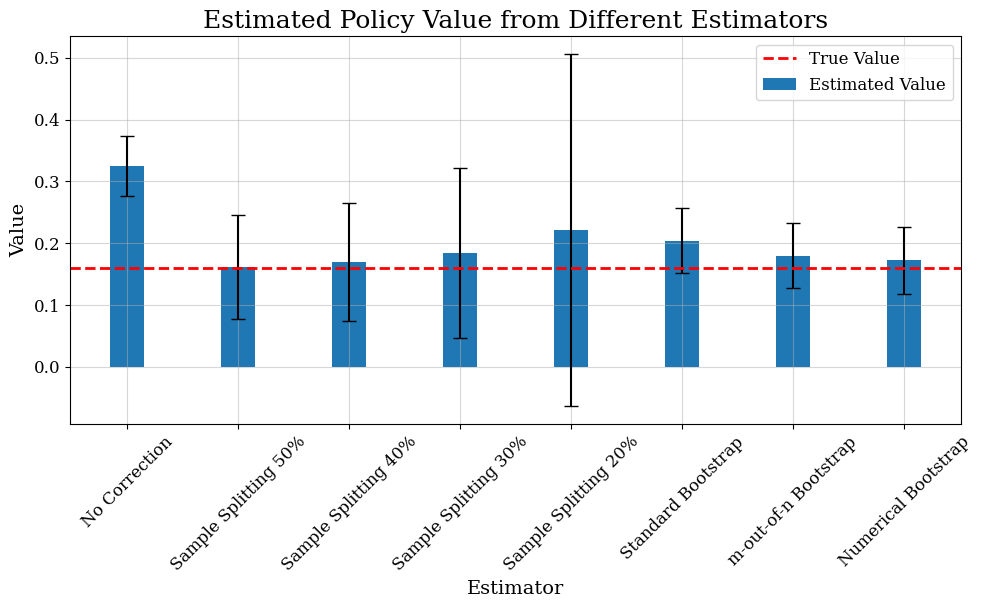

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

viz_estimators_list = ['nc'] + list(estimators_dict.keys())
avg_est_list = [
    wc_measures_dict[f'{estimator}_val_est_avg'] if f'{estimator}_val_est_avg' in wc_measures_dict.keys() else wc_measures_dict['nc_val_est_avg']
    for estimator in viz_estimators_list 
]
se_est_list = [
    wc_measures_dict[f'{estimator}_val_est_se'] if f'{estimator}_val_est_se' in wc_measures_dict.keys() else wc_measures_dict['nc_val_est_se']
    for estimator in viz_estimators_list 
]

ax.bar(
    x=np.arange(len(viz_estimators_list)), 
    height=avg_est_list, 
    yerr=[1.96 * se for se in se_est_list],
    capsize=5, color='C0', width=0.3
)

ax.axhline(wc_measures_dict['nc_val_true_avg'], color='red', linestyle='--', linewidth=2)

ax.set_title("Estimated Policy Value from Different Estimators", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(viz_estimators_list)))
ax.set_xticklabels(['No Correction'] + [estimators_dict[estimator]['display_name'] for estimator in viz_estimators_list[1:]], rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

# ax.set_ylim([0.9, 1.2])

ax.legend(['True Value', 'Estimated Value'], fontsize=legend_label_size)

ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
for te_arr in [[0.01, 0.011], [0.1, 0.11], [0.1, 0.15], [0.1, 0.2], [0.3, 0.4], [0.5, 0.6]]:
    print(f'\n\nTE arr: {te_arr}: ')
    
    operations_params = {}

    dgp_params = {'te_arr': np.array(te_arr), 'noise_std': 1, 'response_type': 'logit'}

    data_params = {'sample_size': 100}

    experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

    estimators_dict = {
        'sample_splitting_50': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.5}, 
            'display_name': 'Sample Splitting 50%'
        }, 
        'sample_splitting_40': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.4}, 
            'display_name': 'Sample Splitting 40%'
        }, 
        'sample_splitting_30': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.3}, 
            'display_name': 'Sample Splitting 30%'
        }, 
        'sample_splitting_20': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.2}, 
            'display_name': 'Sample Splitting 20%'
        }, 
        'standard_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'standard',
            }, 
            'display_name': 'Standard Bootstrap'
        }, 
        'mn_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
                'power': 0.95,
            }, 
            'display_name': 'm-out-of-n Bootstrap'
        }, 
        'num_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
                'power': - 0.45,
            }, 
            'display_name': 'Numerical Bootstrap'
        }, 
    }

    result_records = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, n_jobs=-1
    )

    wc_measures_dict = ts.calculate_winners_curse_measures(
        result_records=result_records,
        estimators_dict=estimators_dict, data_params=data_params
    )

    wc_dict = {}
    delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
    for estimator in ['nc'] + list(estimators_dict.keys()):
        display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

        if f'{estimator}_val_true_avg' in wc_measures_dict.keys():
            avg_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_avg']
            se_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_se']
        else: 
            avg_estimator_val_true = wc_measures_dict['nc_val_true_avg']
            se_estimator_val_true = wc_measures_dict['nc_val_true_se']

        wc_dict.update({
            display_name: {
                "Winner's Curse (%) Avg.": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
                "Winner's Curse (%) S.E.": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
                # 'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
                # 'Correct Decision Rate (%)': 100 * wc_measures_dict[f'{estimator}_correct_decision_rate'], 
                'True Policy Value Avg.': avg_estimator_val_true,
                'True Policy Value S.E.': se_estimator_val_true, 
            }
        })

    wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
    del wc_dict 
    print("Overestimated Profit Lift: ")
    print(wc_df.round(2))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.




TE arr: [0.01, 0.011]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   34.7s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  6.0min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  7.4min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  7.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Winner's Curse (%) Avg.  Winner's Curse (%) S.E.  \
No Correction                        16669.75                  2420.24   
Sample Splitting 50%                  -403.19                  4243.31   
Sample Splitting 40%                   812.11                  4800.90   
Sample Splitting 30%                   896.91                  7210.04   
Sample Splitting 20%                  -942.08                 13507.48   
Standard Bootstrap                    4794.00                  2633.48   
m-out-of-n Bootstrap                  2445.55                  2624.44   
Numerical Bootstrap                   1705.79                  2698.16   

                      True Policy Value Avg.  True Policy Value S.E.  
No Correction                           0.01                     0.0  
Sample Splitting 50%                    0.01                     0.0  
Sample Splitting 40%                    0.01                     0.0  
Sample Splitting 30% 

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   12.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   33.9s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  5.9min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  7.3min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  7.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   35.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  6.0min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  7.5min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  7.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Winner's Curse (%) Avg.  Winner's Curse (%) S.E.  \
No Correction                          167.40                    25.73   
Sample Splitting 50%                     6.92                    43.53   
Sample Splitting 40%                    20.50                    51.76   
Sample Splitting 30%                    51.91                    73.81   
Sample Splitting 20%                   159.87                   166.52   
Standard Bootstrap                      39.20                    27.64   
m-out-of-n Bootstrap                    12.82                    27.44   
Numerical Bootstrap                      5.65                    28.18   

                      True Policy Value Avg.  True Policy Value S.E.  
No Correction                           0.36                     0.0  
Sample Splitting 50%                    0.36                     0.0  
Sample Splitting 40%                    0.36                     0.0  
Sample Splitting 30% 

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   35.9s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  4.9min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  6.2min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  7.7min


Overestimated Profit Lift: 
                      Winner's Curse (%) Avg.  Winner's Curse (%) S.E.  \
No Correction                          176.95                    26.55   
Sample Splitting 50%                    16.13                    45.23   
Sample Splitting 40%                    38.04                    59.26   
Sample Splitting 30%                    74.30                    89.83   
Sample Splitting 20%                   255.83                   191.67   
Standard Bootstrap                      40.04                    28.25   
m-out-of-n Bootstrap                    10.97                    27.96   
Numerical Bootstrap                      4.41                    28.80   

                      True Policy Value Avg.  True Policy Value S.E.  
No Correction                           0.56                     0.0  
Sample Splitting 50%                    0.56                     0.0  
Sample Splitting 40%                    0.56                     0.0  
Sample Splitting 30% 

[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  7.7min finished


In [12]:
for te_arr in [[0.01, 0.011], [0.1, 0.11], [0.1, 0.15], [0.1, 0.2], [0.3, 0.4], [0.5, 0.6]]:
    print(f'\n\nTE arr: {te_arr}: ')
    
    operations_params = {}

    dgp_params = {'te_arr': np.array(te_arr), 'noise_std': 1, 'response_type': 'logit'}

    data_params = {'sample_size': 100}

    experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

    estimators_dict = {
        'sample_splitting_50': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.5}, 
            'display_name': 'Sample Splitting 50%'
        }, 
        'sample_splitting_40': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.4}, 
            'display_name': 'Sample Splitting 40%'
        }, 
        'sample_splitting_30': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.3}, 
            'display_name': 'Sample Splitting 30%'
        }, 
        'sample_splitting_20': {
            'estimator': ts.sample_splitting_estimate, 
            'params': {'hold_out_size': 0.2}, 
            'display_name': 'Sample Splitting 20%'
        }, 
        # 'standard_bootstrap': {
        #     'estimator': ts.bootstrap_correction_estimate, 
        #     'params': {
        #         'n_bootstraps': 500, 'bootstrap_method': 'standard',
        #     }, 
        #     'display_name': 'Standard Bootstrap'
        # }, 
        # 'mn_bootstrap': {
        #     'estimator': ts.bootstrap_correction_estimate, 
        #     'params': {
        #         'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
        #         'power': 0.95,
        #     }, 
        #     'display_name': 'm-out-of-n Bootstrap'
        # }, 
        # 'num_bootstrap': {
        #     'estimator': ts.bootstrap_correction_estimate, 
        #     'params': {
        #         'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
        #         'power': - 0.45,
        #     }, 
        #     'display_name': 'Numerical Bootstrap'
        # }, 
    }

    result_records = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, n_jobs=-1
    )

    wc_measures_dict = ts.calculate_winners_curse_measures(
        result_records=result_records,
        estimators_dict=estimators_dict, data_params=data_params
    )

    wc_dict = {}
    delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
    for estimator in ['nc'] + list(estimators_dict.keys()):
        display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

        if f'{estimator}_val_true_avg' in wc_measures_dict.keys():
            avg_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_avg']
            se_estimator_val_true = wc_measures_dict[f'{estimator}_val_true_se']
        else: 
            avg_estimator_val_true = wc_measures_dict['nc_val_true_avg']
            se_estimator_val_true = wc_measures_dict['nc_val_true_se']

        wc_dict.update({
            display_name: {
                # "Winner's Curse (%) Avg.": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
                # "Winner's Curse (%) S.E.": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
                # 'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
                'Correct Decision Rate (%)': 100 * wc_measures_dict[f'{estimator}_correct_decision_rate'], 
                'True Policy Value Avg.': avg_estimator_val_true,
                'True Policy Value S.E.': se_estimator_val_true, 
            }
        })

    wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
    del wc_dict 
    print("Overestimated Profit Lift: ")
    print(wc_df.round(4))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s




TE arr: [0.01, 0.011]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 3040 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 4800 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    1.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Correct Decision Rate (%)  True Policy Value Avg.  \
No Correction                             49.80                  0.0105   
Sample Splitting 50%                      48.54                  0.0105   
Sample Splitting 40%                      50.06                  0.0105   
Sample Splitting 30%                      50.12                  0.0105   
Sample Splitting 20%                      49.52                  0.0105   

                      True Policy Value S.E.  
No Correction                            0.0  
Sample Splitting 50%                     0.0  
Sample Splitting 40%                     0.0  
Sample Splitting 30%                     0.0  
Sample Splitting 20%                     0.0  


TE arr: [0.1, 0.11]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 3040 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 4800 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    1.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 3040 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 4800 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    1.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Correct Decision Rate (%)  True Policy Value Avg.  \
No Correction                             60.20                  0.3602   
Sample Splitting 50%                      55.86                  0.3559   
Sample Splitting 40%                      56.96                  0.3570   
Sample Splitting 30%                      57.46                  0.3575   
Sample Splitting 20%                      57.82                  0.3578   

                      True Policy Value S.E.  
No Correction                         0.0049  
Sample Splitting 50%                  0.0050  
Sample Splitting 40%                  0.0050  
Sample Splitting 30%                  0.0049  
Sample Splitting 20%                  0.0049  


TE arr: [0.5, 0.6]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 3040 tasks      | elapsed:    1.1s


Overestimated Profit Lift: 
                      Correct Decision Rate (%)  True Policy Value Avg.  \
No Correction                           59.1036                  0.5591   
Sample Splitting 50%                    55.7623                  0.5558   
Sample Splitting 40%                    57.4830                  0.5575   
Sample Splitting 30%                    58.3633                  0.5584   
Sample Splitting 20%                    58.0032                  0.5580   

                      True Policy Value S.E.  
No Correction                         0.0049  
Sample Splitting 50%                  0.0050  
Sample Splitting 40%                  0.0049  
Sample Splitting 30%                  0.0049  
Sample Splitting 20%                  0.0049  


[Parallel(n_jobs=-1)]: Done 4800 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    1.8s finished


# Hyperparameter Optimization

In [16]:
for delta_tau in [0.05, 0.1, 0.5]:
    print(f'\n\nDelta Tau: {delta_tau}: ')
    operations_params = {}

    dgp_params = {'te_arr': np.array([1, 1 + delta_tau]), 'noise_std': 1, 'response_type': 'continuous'}

    data_params = {'sample_size': 100}

    experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

    estimators_dict = {
        'standard_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'standard',
            }, 
            'display_name': 'Standard Bootstrap'
        }, 
        'mn_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
                'power': 'auto', 'n_jobs': 1,
            }, 
            'display_name': 'm-out-of-n Bootstrap'
        }, 
    }

    result_records = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, n_jobs=-1
    )

    wc_measures_dict = ts.calculate_winners_curse_measures(
        result_records=result_records,
        estimators_dict=estimators_dict, data_params=data_params
    )

    wc_dict = {}
    delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
    for estimator in ['nc'] + list(estimators_dict.keys()):
        display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

        wc_dict.update({
            display_name: {
                "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
                "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
                'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            }
        })

    wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
    del wc_dict 
    print("Overestimated Profit Lift: ")
    print(wc_df.round(2))



Delta Tau: 0.05: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   25.6s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   37.5s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   51.5s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Avg. Winner's Curse (%)  S.E. Winner's Curse (%)  \
No Correction                          156.27                    23.55   
Standard Bootstrap                      46.87                    26.10   
m-out-of-n Bootstrap                   -30.44                    26.60   

                      Median Winner's Curse (%)  
No Correction                            150.76  
Standard Bootstrap                        35.70  
m-out-of-n Bootstrap                     -41.54  


Delta Tau: 0.1: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   25.8s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   37.4s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   51.2s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Avg. Winner's Curse (%)  S.E. Winner's Curse (%)  \
No Correction                           71.49                    12.15   
Standard Bootstrap                      19.04                    13.38   
m-out-of-n Bootstrap                   -19.13                    13.66   

                      Median Winner's Curse (%)  
No Correction                             67.85  
Standard Bootstrap                        13.54  
m-out-of-n Bootstrap                     -25.15  


Delta Tau: 0.5: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   25.6s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   37.2s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   50.9s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.7min


Overestimated Profit Lift: 
                      Avg. Winner's Curse (%)  S.E. Winner's Curse (%)  \
No Correction                           -0.02                     2.84   
Standard Bootstrap                      -2.47                     3.05   
m-out-of-n Bootstrap                    -7.55                     3.27   

                      Median Winner's Curse (%)  
No Correction                             -0.24  
Standard Bootstrap                        -1.53  
m-out-of-n Bootstrap                      -6.20  


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  1.8min finished


In [17]:
for te_arr in [[0.01, 0.011], [0.1, 0.11], [0.1, 0.15], [0.1, 0.2], [0.3, 0.4], [0.5, 0.6]]:
    print(f'\n\nTE arr: {te_arr}: ')
    operations_params = {}

    dgp_params = {'te_arr': np.array(te_arr), 'noise_std': 1, 'response_type': 'bernoulli'}

    data_params = {'sample_size': 100}

    experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

    estimators_dict = {
        'standard_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'standard',
            }, 
            'display_name': 'Standard Bootstrap'
        }, 
        'mn_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
                'power': 'auto', 'n_jobs': 1,
            }, 
            'display_name': 'm-out-of-n Bootstrap'
        }, 
    }

    result_records = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, n_jobs=-1
    )

    wc_measures_dict = ts.calculate_winners_curse_measures(
        result_records=result_records,
        estimators_dict=estimators_dict, data_params=data_params
    )

    wc_dict = {}
    delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
    for estimator in ['nc'] + list(estimators_dict.keys()):
        display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

        wc_dict.update({
            display_name: {
                "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
                "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
                'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            }
        })

    wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
    del wc_dict 
    print("Overestimated Profit Lift: ")
    print(wc_df.round(2))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.




TE arr: [0.01, 0.011]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   36.9s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   50.7s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Avg. Winner's Curse (%)  S.E. Winner's Curse (%)  \
No Correction                          716.89                   160.69   
Standard Bootstrap                     367.88                   144.72   
m-out-of-n Bootstrap                    89.62                   140.55   

                      Median Winner's Curse (%)  
No Correction                            860.78  
Standard Bootstrap                       123.76  
m-out-of-n Bootstrap                    -545.76  


TE arr: [0.1, 0.11]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   37.1s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   50.9s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   25.3s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   37.0s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   50.8s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Avg. Winner's Curse (%)  S.E. Winner's Curse (%)  \
No Correction                           20.92                     6.52   
Standard Bootstrap                       0.51                     7.08   
m-out-of-n Bootstrap                   -10.98                     7.26   

                      Median Winner's Curse (%)  
No Correction                             20.00  
Standard Bootstrap                        -0.43  
m-out-of-n Bootstrap                     -12.87  


TE arr: [0.5, 0.6]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   25.3s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   37.0s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:   50.7s
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  1.7min


Overestimated Profit Lift: 
                      Avg. Winner's Curse (%)  S.E. Winner's Curse (%)  \
No Correction                           24.70                     6.58   
Standard Bootstrap                       3.09                     7.23   
m-out-of-n Bootstrap                    -7.72                     7.44   

                      Median Winner's Curse (%)  
No Correction                             22.64  
Standard Bootstrap                         1.75  
m-out-of-n Bootstrap                      -9.24  


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  1.8min finished


In [18]:
for te_arr in [[0.01, 0.011], [0.1, 0.11], [0.1, 0.15], [0.1, 0.2], [0.3, 0.4], [0.5, 0.6]]:
    print(f'\n\nTE arr: {te_arr}: ')
    operations_params = {}

    dgp_params = {'te_arr': np.array(te_arr), 'noise_std': 1, 'response_type': 'logit'}

    data_params = {'sample_size': 100}

    experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

    estimators_dict = {
        'standard_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'standard',
            }, 
            'display_name': 'Standard Bootstrap'
        }, 
        'mn_bootstrap': {
            'estimator': ts.bootstrap_correction_estimate, 
            'params': {
                'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
                'power': 'auto', 'n_jobs': 1,
            }, 
            'display_name': 'm-out-of-n Bootstrap'
        }, 
    }

    result_records = ts.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, n_jobs=-1
    )

    wc_measures_dict = ts.calculate_winners_curse_measures(
        result_records=result_records,
        estimators_dict=estimators_dict, data_params=data_params
    )

    wc_dict = {}
    delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
    for estimator in ['nc'] + list(estimators_dict.keys()):
        display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

        wc_dict.update({
            display_name: {
                "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
                "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
                'Median Winner\'s Curse (%)': 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            }
        })

    wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
    del wc_dict 
    print("Overestimated Profit Lift: ")
    print(wc_df.round(2))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.




TE arr: [0.01, 0.011]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed: 11.0min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed: 13.6min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed: 13.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Avg. Winner's Curse (%)  S.E. Winner's Curse (%)  \
No Correction                        16669.75                  2420.24   
Standard Bootstrap                    4801.03                  2634.04   
m-out-of-n Bootstrap                  -712.52                  2671.22   

                      Median Winner's Curse (%)  
No Correction                          16335.34  
Standard Bootstrap                      3832.86  
m-out-of-n Bootstrap                   -1988.91  


TE arr: [0.1, 0.11]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed: 11.0min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed: 13.7min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed: 13.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  4.9min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  6.7min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed: 11.1min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed: 13.7min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed: 13.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Overestimated Profit Lift: 
                      Avg. Winner's Curse (%)  S.E. Winner's Curse (%)  \
No Correction                          166.30                    25.69   
Standard Bootstrap                      38.28                    27.62   
m-out-of-n Bootstrap                   -22.03                    27.90   

                      Median Winner's Curse (%)  
No Correction                            152.08  
Standard Bootstrap                        19.77  
m-out-of-n Bootstrap                     -40.31  


TE arr: [0.5, 0.6]: 
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   25.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed: 11.1min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed: 13.7min


Overestimated Profit Lift: 
                      Avg. Winner's Curse (%)  S.E. Winner's Curse (%)  \
No Correction                          167.83                    25.91   
Standard Bootstrap                      31.50                    27.72   
m-out-of-n Bootstrap                   -37.70                    27.98   

                      Median Winner's Curse (%)  
No Correction                            157.69  
Standard Bootstrap                        14.16  
m-out-of-n Bootstrap                     -57.71  


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed: 13.9min finished
